# PROYECTO: COMPARACIÓN DE ARQUITECTURAS - Clasificación de Enfermedades en Hojas de Yuca

---

En este proyecto, vamos a comparar **3 arquitecturas diferentes** de redes neuronales para resolver el problema de clasificación de imágenes de enfermedades en hojas de yuca (cassava):

1. **Red Neuronal Densa (DNN)** - Baseline con capas fully connected
2. **Red Neuronal Convolucional (CNN)** - CNN entrenada desde cero
3. **Transfer Learning (CNN pre-entrenada)** - Aprovechando modelos pre-entrenados

**Dataset:** Cassava Leaf Disease Classification

[Dataset en Kaggle](https://www.kaggle.com/datasets/nirmalsankalana/cassava-leaf-disease-classification)

**Objetivo:** Comparar el rendimiento de las 3 arquitecturas y determinar cuál es más efectiva para este problema de clasificación de enfermedades en plantas.

**Contexto:** La yuca (cassava) es un cultivo crucial para la seguridad alimentaria en África tropical. Las enfermedades virales son una de las principales causas de pérdida de cultivos. Este proyecto busca desarrollar un sistema de clasificación para identificar automáticamente enfermedades en hojas de yuca mediante visión por computadora.

**Clases de enfermedades:**
- Cassava Bacterial Blight (CBB)
- Cassava Brown Streak Disease (CBSD)
- Cassava Green Mottle (CGM)
- Cassava Mosaic Disease (CMD)
- Healthy (sanas)

**Ventajas de cada arquitectura:**
- **DNN**: Simple, rápida, baseline para comparación
- **CNN**: Aprende características espaciales, mejor para imágenes
- **Transfer Learning**: Aprovecha conocimiento previo, mejor generalización con menos datos


## Instalación de Dependencias

**⚠️ IMPORTANTE:** Ejecuta esta celda solo si necesitas instalar las dependencias. Si ya tienes un entorno configurado (como `venv_tf_gpu`), puedes omitir esta celda.

**Versiones específicas para compatibilidad:**
- TensorFlow 2.10.0 (última versión compatible con Python 3.9 y GPU)
- NumPy < 2.0 (TensorFlow 2.10 no es compatible con NumPy 2.x)
- OpenCV < 4.10 (compatible con NumPy 1.x)

In [1]:
!pip install "opencv-python<4.10"
!pip install pandas scikit-learn
!pip install matplotlib seaborn
!pip install kagglehub
!pip install tensorflow==2.10.0 tensorflow-gpu==2.10.0
!pip install "numpy<2.0"

   ---------------------------------------- 0.0/455.9 MB ? eta -:--:--
   ---------------------------------------- 1.6/455.9 MB 9.3 MB/s eta 0:00:49
   ---------------------------------------- 4.2/455.9 MB 10.9 MB/s eta 0:00:42
    --------------------------------------- 7.1/455.9 MB 12.1 MB/s eta 0:00:38
    --------------------------------------- 10.5/455.9 MB 13.3 MB/s eta 0:00:34
   - -------------------------------------- 12.3/455.9 MB 12.1 MB/s eta 0:00:37
   - -------------------------------------- 15.5/455.9 MB 12.5 MB/s eta 0:00:36
   - -------------------------------------- 20.2/455.9 MB 13.9 MB/s eta 0:00:32
   -- ------------------------------------- 24.4/455.9 MB 14.7 MB/s eta 0:00:30
   -- ------------------------------------- 28.8/455.9 MB 15.5 MB/s eta 0:00:28
   -- ------------------------------------- 33.3/455.9 MB 16.0 MB/s eta 0:00:27
   --- ------------------------------------ 38.0/455.9 MB 16.5 MB/s eta 0:00:26
   --- ------------------------------------ 41.9/455.

## Configuración Inicial - GPU

In [2]:
# Configurar TensorFlow para usar GPU
import os
import tensorflow as tf

print("="*80)
print("CONFIGURACIÓN DE GPU CON TENSORFLOW")
print("="*80 + "\n")

# Verificar versión de TensorFlow
print(f"TensorFlow version: {tf.__version__}")

# Configurar para usar GPU si está disponible
gpus = tf.config.list_physical_devices('GPU')
print(f"\nGPUs detectadas: {len(gpus)}")

if gpus:
    try:
        # Permitir crecimiento de memoria para evitar que TensorFlow reserve toda la VRAM
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        
        print(f"✅ GPU configurada correctamente")
        print(f"   Dispositivo: {gpus[0].name}")
        
        # Información adicional de la GPU
        gpu_details = tf.config.experimental.get_device_details(gpus[0])
        if 'device_name' in gpu_details:
            print(f"   Nombre: {gpu_details['device_name']}")
        
    except RuntimeError as e:
        print(f"⚠️ Error configurando GPU: {e}")
else:
    print("⚠️ No se detectaron GPUs. Se usará CPU (entrenamiento más lento)")
    print("   Asegúrate de tener CUDA y cuDNN instalados correctamente.")

# Verificar dispositivo por defecto
print(f"\nDispositivo por defecto: {tf.test.gpu_device_name() if tf.test.is_gpu_available() else 'CPU'}")

print("\n" + "="*80)

CONFIGURACIÓN DE GPU CON TENSORFLOW

TensorFlow version: 2.10.0

GPUs detectadas: 1
✅ GPU configurada correctamente
   Dispositivo: /physical_device:GPU:0
   Nombre: NVIDIA GeForce RTX 4060 Ti
Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.

Dispositivo por defecto: /device:GPU:0



## Importación de Librerías

In [3]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16, ResNet50, EfficientNetB0, MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# Configurar semillas para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("✅ Librerías importadas correctamente")
print(f"   Keras version: {keras.__version__}")
print(f"   Numpy version: {np.__version__}")

✅ Librerías importadas correctamente
   Keras version: 2.10.0
   Numpy version: 1.26.4


## Descarga del Dataset

In [ ]:
# Descargar el dataset desde Kaggle usando kagglehub
!pip install -q kagglehub

import kagglehub

print("="*80)
print("DESCARGA DEL DATASET DE ENFERMEDADES EN HOJAS DE YUCA")
print("="*80 + "\n")

print("Descargando dataset de Cassava Leaf Disease Classification desde Kaggle...")
print("Esto puede tardar varios minutos dependiendo de tu conexión...\n")

try:
    # Descargar la última versión del dataset
    path = kagglehub.dataset_download("nirmalsankalana/cassava-leaf-disease-classification")

    print(f"\n✅ Dataset descargado correctamente en: {path}")
    print(f"\nContenido del directorio:")

    for item in os.listdir(path):
        item_path = os.path.join(path, item)
        if os.path.isdir(item_path):
            # Contar archivos de imagen
            image_files = [f for f in os.listdir(item_path) 
                          if f.lower().endswith(('.jpeg', '.jpg', '.png', '.bmp'))]
            print(f"  📁 {item}/ ({len(image_files)} imágenes)")
        else:
            print(f"  📄 {item}")

except Exception as e:
    print(f"\n❌ Error al descargar el dataset: {e}")
    raise

print("\n" + "="*80)


DESCARGA DEL DATASET DE MELANOMA

Descargando dataset de Melanoma (10,000 imágenes) desde Kaggle...
Esto puede tardar varios minutos dependiendo de tu conexión...


✅ Dataset descargado correctamente en: C:\Users\TRENDINGPC\.cache\kagglehub\datasets\hasnainjaved\melanoma-skin-cancer-dataset-of-10000-images\versions\1

Contenido del directorio:
  📁 melanoma_cancer_dataset/ (0 imágenes)



## Configuración y Carga de Datos

In [ ]:
# Configuración
IMG_SIZE = 224  # Tamaño estándar para modelos pre-entrenados (VGG, ResNet, etc.)
BATCH_SIZE = 32
EPOCHS = 50

# Explorar la estructura del dataset
print("="*80)
print("EXPLORACIÓN DEL DATASET DE CASSAVA")
print("="*80 + "\n")

if 'path' in locals():
    print(f"Ruta del dataset: {path}\n")
    
    # Buscar carpeta principal del dataset
    dataset_root = None
    for item in os.listdir(path):
        item_path = os.path.join(path, item)
        if os.path.isdir(item_path):
            # Verificar si contiene train y test
            subdirs = os.listdir(item_path) if os.path.exists(item_path) else []
            if 'train' in subdirs and 'test' in subdirs:
                dataset_root = item_path
                break
    
    # Si no se encuentra, usar la ruta directamente
    if dataset_root is None:
        subdirs = os.listdir(path)
        if 'train' in subdirs and 'test' in subdirs:
            dataset_root = path
    
    if dataset_root:
        DATASET_PATH = dataset_root
        TRAIN_PATH = os.path.join(dataset_root, 'train')
        TEST_PATH = os.path.join(dataset_root, 'test')
        
        print(f"📁 Estructura del dataset:")
        print(f"   Root: {dataset_root}")
        print(f"   Train: {TRAIN_PATH}")
        print(f"   Test: {TEST_PATH}\n")
        
        # Explorar clases en train
        class_folders = []
        if os.path.exists(TRAIN_PATH):
            for item in os.listdir(TRAIN_PATH):
                item_path = os.path.join(TRAIN_PATH, item)
                if os.path.isdir(item_path):
                    image_files = [f for f in os.listdir(item_path) 
                                 if f.lower().endswith(('.jpeg', '.jpg', '.png', '.bmp'))]
                    if image_files:
                        class_folders.append(item)
                        print(f"📁 Clase en Train: {item} ({len(image_files)} imágenes)")
        
        # Explorar clases en test
        if os.path.exists(TEST_PATH):
            print()
            for item in os.listdir(TEST_PATH):
                item_path = os.path.join(TEST_PATH, item)
                if os.path.isdir(item_path):
                    image_files = [f for f in os.listdir(item_path) 
                                 if f.lower().endswith(('.jpeg', '.jpg', '.png', '.bmp'))]
                    if image_files:
                        print(f"📁 Clase en Test: {item} ({len(image_files)} imágenes)")
        
        if class_folders:
            # Mapeo de clases para el dataset de Cassava
            # Orden alfabético para mantener consistencia
            sorted_classes = sorted(class_folders)
            MAP_CLASSES = {i: folder for i, folder in enumerate(sorted_classes)}
            
            # Nombres descriptivos para cada enfermedad
            CLASS_NAMES = {}
            for idx, folder in enumerate(sorted_classes):
                if 'cbb' in folder.lower():
                    CLASS_NAMES[idx] = 'Cassava Bacterial Blight (CBB)'
                elif 'cbsd' in folder.lower():
                    CLASS_NAMES[idx] = 'Cassava Brown Streak Disease (CBSD)'
                elif 'cgm' in folder.lower():
                    CLASS_NAMES[idx] = 'Cassava Green Mottle (CGM)'
                elif 'cmd' in folder.lower():
                    CLASS_NAMES[idx] = 'Cassava Mosaic Disease (CMD)'
                elif 'healthy' in folder.lower():
                    CLASS_NAMES[idx] = 'Healthy (Sana)'
                else:
                    CLASS_NAMES[idx] = folder.replace('_', ' ').title()
            
            print(f"\n✅ Encontradas {len(MAP_CLASSES)} clases de enfermedades de yuca:")
            for idx, name in CLASS_NAMES.items():
                print(f"   {idx}: {name}")
        else:
            print("❌ No se encontraron carpetas con imágenes en train")
    else:
        print("❌ No se encontró la estructura train/test en el dataset")
else:
    print("❌ Variable 'path' no encontrada. Ejecuta la celda de descarga primero.")

print("\n" + "="*80)


EXPLORACIÓN DEL DATASET

Ruta del dataset: C:\Users\TRENDINGPC\.cache\kagglehub\datasets\hasnainjaved\melanoma-skin-cancer-dataset-of-10000-images\versions\1

📁 Estructura del dataset:
   Root: C:\Users\TRENDINGPC\.cache\kagglehub\datasets\hasnainjaved\melanoma-skin-cancer-dataset-of-10000-images\versions\1\melanoma_cancer_dataset
   Train: C:\Users\TRENDINGPC\.cache\kagglehub\datasets\hasnainjaved\melanoma-skin-cancer-dataset-of-10000-images\versions\1\melanoma_cancer_dataset\train
   Test: C:\Users\TRENDINGPC\.cache\kagglehub\datasets\hasnainjaved\melanoma-skin-cancer-dataset-of-10000-images\versions\1\melanoma_cancer_dataset\test

📁 Clase en Train: benign (5000 imágenes)
📁 Clase en Train: malignant (4605 imágenes)

📁 Clase en Test: benign (500 imágenes)
📁 Clase en Test: malignant (500 imágenes)

✅ Encontradas 2 clases:
   0: Benign
   1: Malignant



In [ ]:
def load_cassava_dataset(dirname, map_classes, img_size=224, verbose=True):
    """Carga el dataset de enfermedades de hojas de yuca.
    
    Args:
        dirname: directorio con las imágenes organizadas por carpetas
        map_classes: diccionario de mapeo clase -> nombre de carpeta
        img_size: tamaño al que redimensionar las imágenes
        verbose: mostrar información de progreso
    
    Returns:
        X, y: arrays con imágenes y etiquetas
    """
    X_data = []
    y_data = []
    
    for label, class_name in map_classes.items():
        class_path = os.path.join(dirname, class_name)
        
        if not os.path.exists(class_path):
            if verbose:
                print(f"⚠️ Carpeta no encontrada: {class_path}")
            continue
        
        files = os.listdir(class_path)
        images = [f for f in files if f.lower().endswith(('.jpeg', '.jpg', '.png', '.bmp'))]
        
        if verbose:
            print(f"Cargando {len(images)} imágenes de '{CLASS_NAMES[label]}'...")
        
        for i, image_name in enumerate(images):
            try:
                image_path = os.path.join(class_path, image_name)
                image = cv2.imread(image_path)
                
                if image is not None:
                    # Convertir de BGR a RGB
                    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                    # Redimensionar
                    image = cv2.resize(image, (img_size, img_size))
                    
                    X_data.append(image)
                    y_data.append(label)
                else:
                    if verbose and i < 5:  # Solo mostrar algunos errores
                        print(f"  ⚠️ No se pudo leer: {image_name}")
            except Exception as e:
                if verbose and i < 5:
                    print(f"  ⚠️ Error procesando {image_name}: {e}")
    
    return np.array(X_data), np.array(y_data)

print("✅ Función de carga definida")


✅ Función de carga definida


In [ ]:
# Cargar el dataset
print("="*80)
print("CARGANDO DATASET DE ENFERMEDADES DE HOJAS DE YUCA")
print("="*80 + "\n")

# Cargar datos de entrenamiento
print("Cargando datos de TRAIN...")
X_train, y_train = load_cassava_dataset(TRAIN_PATH, MAP_CLASSES, img_size=IMG_SIZE)

print(f"\n✅ Datos de TRAIN cargados:")
print(f"   X_train shape: {X_train.shape}")
print(f"   y_train shape: {y_train.shape}")
print(f"   Rango de valores de pixeles: [{X_train.min()}, {X_train.max()}]")

# Cargar datos de test
print(f"\n{'='*80}\n")
print("Cargando datos de TEST...")
X_test, y_test = load_cassava_dataset(TEST_PATH, MAP_CLASSES, img_size=IMG_SIZE)

print(f"\n✅ Datos de TEST cargados:")
print(f"   X_test shape: {X_test.shape}")
print(f"   y_test shape: {y_test.shape}")
print(f"   Rango de valores de pixeles: [{X_test.min()}, {X_test.max()}]")

# Estadísticas del dataset
print(f"\n{'='*80}")
print("ESTADÍSTICAS DEL DATASET")
print("="*80 + "\n")

print(f"Total de imágenes:")
print(f"  - Entrenamiento: {len(X_train)}")
print(f"  - Test: {len(X_test)}")
print(f"  - Total: {len(X_train) + len(X_test)}")

print(f"\nDistribución de clases en TRAIN:")
unique_train, counts_train = np.unique(y_train, return_counts=True)
for label, count in zip(unique_train, counts_train):
    print(f"  {CLASS_NAMES[label]}: {count} imágenes ({count/len(y_train)*100:.1f}%)")

print(f"\nDistribución de clases en TEST:")
unique_test, counts_test = np.unique(y_test, return_counts=True)
for label, count in zip(unique_test, counts_test):
    print(f"  {CLASS_NAMES[label]}: {count} imágenes ({count/len(y_test)*100:.1f}%)")

print(f"\n{'='*80}")


CARGANDO DATASET DE MELANOMA

Cargando datos de TRAIN...
Cargando 5000 imágenes de 'Benign'...
Cargando 4605 imágenes de 'Malignant'...

Cargando datos de TEST...
Cargando 500 imágenes de 'Benign'...
Cargando 500 imágenes de 'Malignant'...

✅ Dataset cargado exitosamente!

📊 Conjunto de TRAIN:
   Total de imágenes: 9,605
   Forma de X_train: (9605, 224, 224, 3)
   Clases únicas: [0 1]

📊 Conjunto de TEST:
   Total de imágenes: 1,000
   Forma de X_test: (1000, 224, 224, 3)
   Clases únicas: [0 1]

📊 Rango de valores de píxeles: [0, 255]

Barajando datos de entrenamiento...
✅ Datos barajados



## Análisis Exploratorio de Datos

ANÁLISIS EXPLORATORIO DEL DATASET DE MELANOMA

--- Distribución de Clases en TRAIN ---
    Clase  Cantidad  Porcentaje
   Benign      5000       52.06
Malignant      4605       47.94

--- Distribución de Clases en TEST ---
    Clase  Cantidad  Porcentaje
   Benign       500        50.0
Malignant       500        50.0


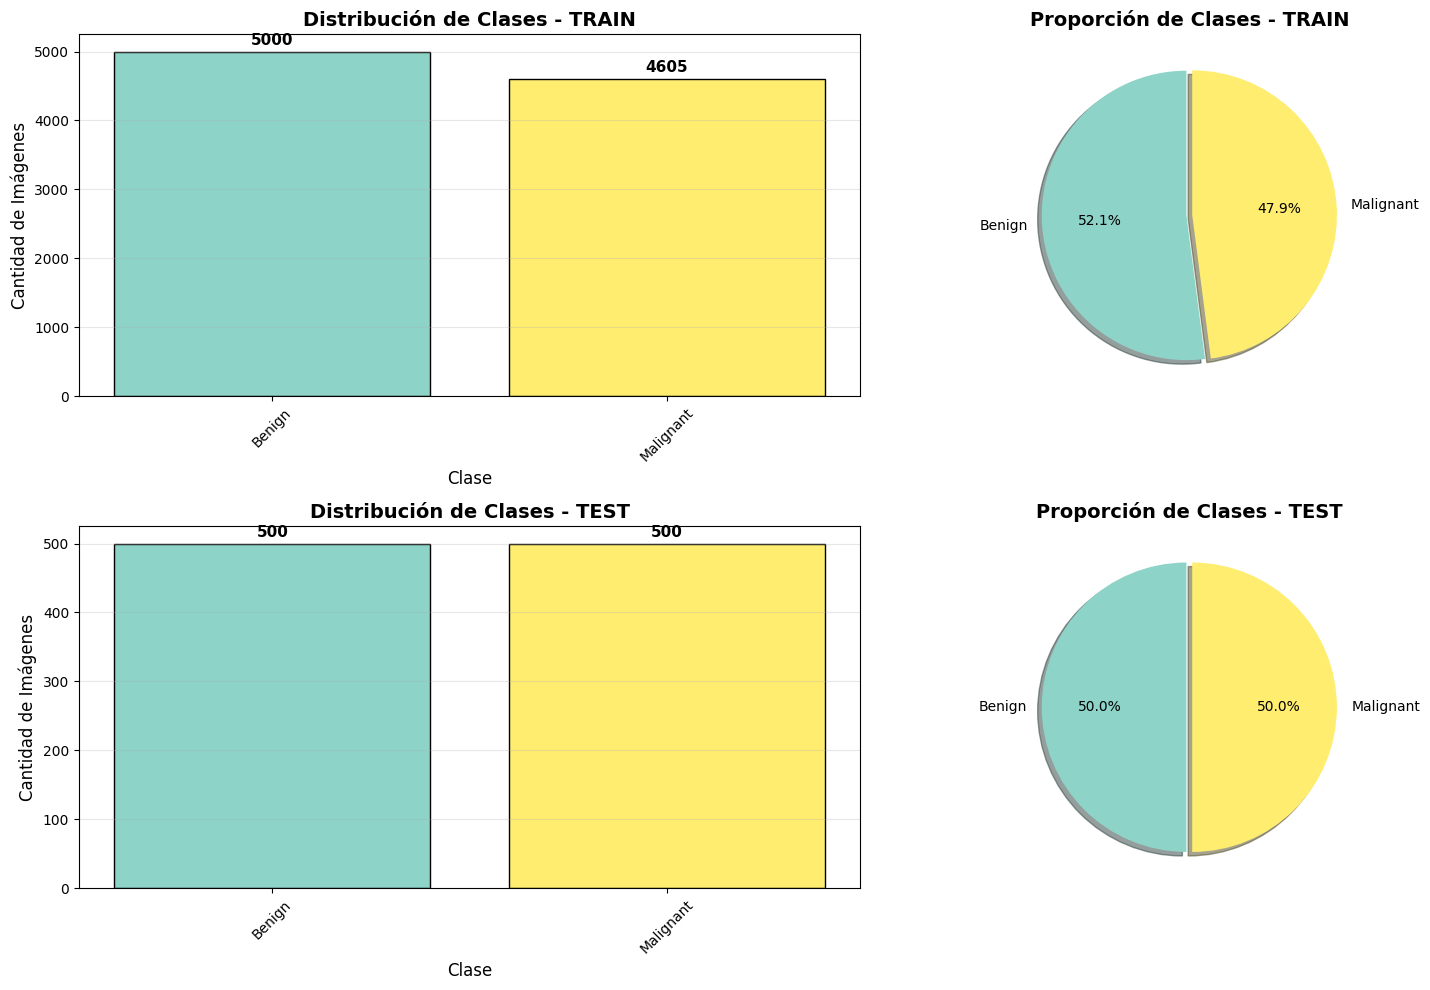

In [ ]:
print("="*80)
print("ANÁLISIS EXPLORATORIO DEL DATASET DE ENFERMEDADES DE YUCA")
print("="*80 + "\n")

# Distribución de clases en TRAIN
print("--- Distribución de Clases en TRAIN ---")
unique_train, counts_train = np.unique(y_train, return_counts=True)
df_dist_train = pd.DataFrame({
    'Clase': [CLASS_NAMES[i] for i in unique_train],
    'Cantidad': counts_train,
    'Porcentaje': (counts_train / len(y_train) * 100).round(2)
})
print(df_dist_train.to_string(index=False))

# Distribución de clases en TEST
print("\n--- Distribución de Clases en TEST ---")
unique_test, counts_test = np.unique(y_test, return_counts=True)
df_dist_test = pd.DataFrame({
    'Clase': [CLASS_NAMES[i] for i in unique_test],
    'Cantidad': counts_test,
    'Porcentaje': (counts_test / len(y_test) * 100).round(2)
})
print(df_dist_test.to_string(index=False))

# Visualización
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

colors = plt.cm.Set3(np.linspace(0, 1, len(unique_train)))

# TRAIN - Gráfico de barras
ax1 = axes[0, 0]
ax1.bar([CLASS_NAMES[i] for i in unique_train], counts_train, color=colors, edgecolor='black')
ax1.set_xlabel('Clase', fontsize=12)
ax1.set_ylabel('Cantidad de Imágenes', fontsize=12)
ax1.set_title('Distribución de Clases - TRAIN', fontsize=14, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)
for i, (v, c) in enumerate(zip(counts_train, counts_train)):
    ax1.text(i, v + max(counts_train)*0.02, str(c), ha='center', fontsize=11, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# TRAIN - Gráfico circular
ax2 = axes[0, 1]
ax2.pie(counts_train, labels=[CLASS_NAMES[i] for i in unique_train], autopct='%1.1f%%',
        colors=colors, explode=[0.02]*len(unique_train), shadow=True, startangle=90)
ax2.set_title('Proporción de Clases - TRAIN', fontsize=14, fontweight='bold')

# TEST - Gráfico de barras
ax3 = axes[1, 0]
ax3.bar([CLASS_NAMES[i] for i in unique_test], counts_test, color=colors, edgecolor='black')
ax3.set_xlabel('Clase', fontsize=12)
ax3.set_ylabel('Cantidad de Imágenes', fontsize=12)
ax3.set_title('Distribución de Clases - TEST', fontsize=14, fontweight='bold')
ax3.tick_params(axis='x', rotation=45)
for i, (v, c) in enumerate(zip(counts_test, counts_test)):
    ax3.text(i, v + max(counts_test)*0.02, str(c), ha='center', fontsize=11, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

# TEST - Gráfico circular
ax4 = axes[1, 1]
ax4.pie(counts_test, labels=[CLASS_NAMES[i] for i in unique_test], autopct='%1.1f%%',
        colors=colors, explode=[0.02]*len(unique_test), shadow=True, startangle=90)
ax4.set_title('Proporción de Clases - TEST', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*80)


Visualizando muestras del dataset de TRAIN...



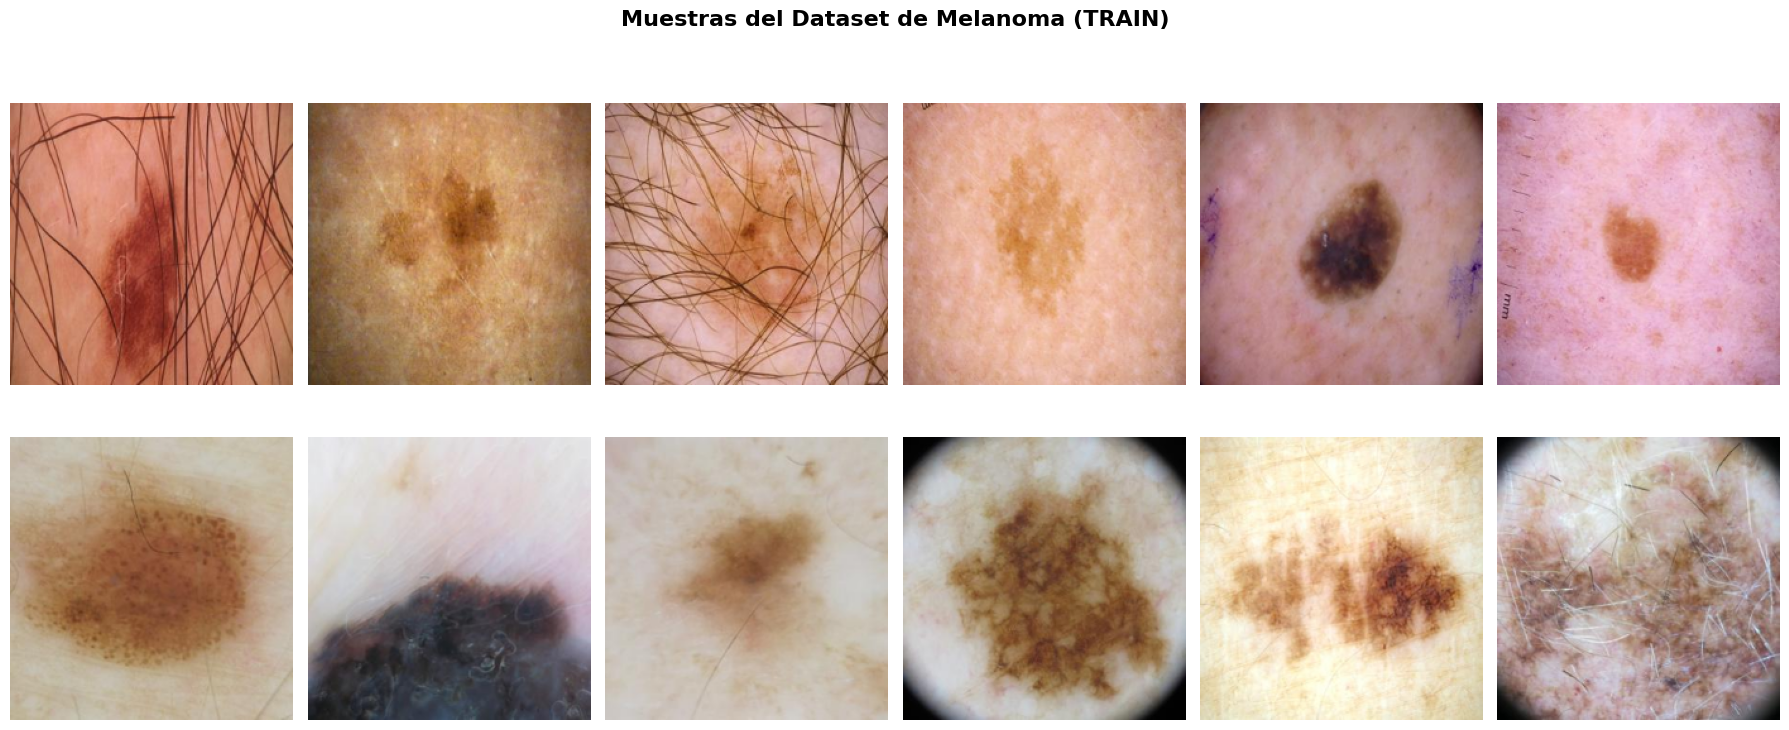

In [ ]:
# Visualizar muestras de cada clase (de TRAIN)
print("Visualizando muestras del dataset de TRAIN...\n")

n_classes = len(MAP_CLASSES)
samples_per_class = 6

fig, axes = plt.subplots(n_classes, samples_per_class, figsize=(18, 4*n_classes))

if n_classes == 1:
    axes = [axes]

for idx, label in enumerate(sorted(MAP_CLASSES.keys())):
    indices = np.where(y_train == label)[0]
    np.random.shuffle(indices)
    
    for i in range(min(samples_per_class, len(indices))):
        ax = axes[idx][i] if n_classes > 1 else axes[i]
        ax.imshow(X_train[indices[i]])
        ax.axis('off')
        if i == 0:
            ax.set_ylabel(CLASS_NAMES[label], fontsize=12, rotation=0, 
                         ha='right', va='center')

plt.suptitle('Muestras del Dataset de Enfermedades de Hojas de Yuca (TRAIN)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


## Preparación de Datos

In [10]:
print("="*80)
print("PREPARACIÓN DE DATOS")
print("="*80 + "\n")

# Normalizar las imágenes (importante para Transfer Learning)
print("Normalizando imágenes para Transfer Learning...")
# Los modelos pre-entrenados esperan valores en [0, 1] o normalizados según ImageNet
X_train_normalized = X_train.astype('float32') / 255.0
X_test_normalized = X_test.astype('float32') / 255.0

print(f"Rango normalizado TRAIN: [{X_train_normalized.min():.2f}, {X_train_normalized.max():.2f}]")
print(f"Rango normalizado TEST: [{X_test_normalized.min():.2f}, {X_test_normalized.max():.2f}]")

# Convertir etiquetas a one-hot encoding
print("\nConvirtiendo etiquetas a one-hot encoding...")
y_train_categorical = keras.utils.to_categorical(y_train, len(MAP_CLASSES))
y_test_categorical = keras.utils.to_categorical(y_test, len(MAP_CLASSES))
print(f"Forma de y_train_categorical: {y_train_categorical.shape}")
print(f"Forma de y_test_categorical: {y_test_categorical.shape}")

# Crear conjunto de VALIDATION a partir de TRAIN (20% del train)
print("\nCreando conjunto de VALIDATION a partir de TRAIN (80/20)...")
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_normalized, y_train_categorical,
    test_size=0.20,
    random_state=SEED,
    stratify=y_train
)

# Etiquetas sin one-hot para métricas
y_train_labels = np.argmax(y_train_final, axis=1)
y_val_labels = np.argmax(y_val, axis=1)
y_test_labels = np.argmax(y_test_categorical, axis=1)

print(f"\n📊 Resumen de la división final:")
print(f"   Training: {X_train_final.shape[0]:,} imágenes ({X_train_final.shape[0]/(len(X_train)+len(X_test))*100:.1f}% del total)")
print(f"   Validation: {X_val.shape[0]:,} imágenes ({X_val.shape[0]/(len(X_train)+len(X_test))*100:.1f}% del total)")
print(f"   Test: {X_test_normalized.shape[0]:,} imágenes ({len(X_test)/(len(X_train)+len(X_test))*100:.1f}% del total)")

# Verificar distribución
print("\n📊 Distribución de clases por conjunto:")
for name, labels in [("Training", y_train_labels),
                      ("Validation", y_val_labels),
                      ("Test", y_test_labels)]:
    unique_labels, counts_labels = np.unique(labels, return_counts=True)
    dist_str = ", ".join([f"{CLASS_NAMES[l]}={c}" for l, c in zip(unique_labels, counts_labels)])
    print(f"   {name}: {dist_str}")

print("\n" + "="*80)


PREPARACIÓN DE DATOS

Normalizando imágenes para Transfer Learning...
Rango normalizado TRAIN: [0.00, 1.00]
Rango normalizado TEST: [0.00, 1.00]

Convirtiendo etiquetas a one-hot encoding...
Forma de y_train_categorical: (9605, 2)
Forma de y_test_categorical: (1000, 2)

Creando conjunto de VALIDATION a partir de TRAIN (80/20)...

📊 Resumen de la división final:
   Training: 7,684 imágenes (72.5% del total)
   Validation: 1,921 imágenes (18.1% del total)
   Test: 1,000 imágenes (9.4% del total)

📊 Distribución de clases por conjunto:
   Training: Benign=4000, Malignant=3684
   Validation: Benign=1000, Malignant=921
   Test: Benign=500, Malignant=500



## MODELO 1: Red Neuronal Densa (DNN)

In [11]:
print("="*80)
print("MODELO 1: RED NEURONAL DENSA (DNN)")
print("="*80 + "\n")

print("Características de las redes neuronales densas:")
print("  • Todas las neuronas están conectadas entre capas")
print("  • No explotan la estructura espacial de las imágenes")
print("  • Requieren aplanar las imágenes (pérdida de información espacial)")
print("  • Sirven como baseline para comparación\n")

# Aplanar las imágenes para DNN
print("Preparando datos para DNN (aplanando imágenes)...")
X_train_flat = X_train_final.reshape(X_train_final.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_test_flat = X_test_normalized.reshape(X_test_normalized.shape[0], -1)

print(f"Forma original: {X_train_final.shape}")
print(f"Forma aplanada: {X_train_flat.shape}")
print(f"Tamaño de entrada: {X_train_flat.shape[1]:,} features\n")

# Construir modelo DNN
print("Construyendo modelo DNN...")

model_dnn = models.Sequential([
    layers.Input(shape=(IMG_SIZE * IMG_SIZE * 3,)),
    
    layers.Dense(512, activation='relu', name='dense1'),
    layers.BatchNormalization(name='bn1'),
    layers.Dropout(0.5, name='dropout1'),
    
    layers.Dense(256, activation='relu', name='dense2'),
    layers.BatchNormalization(name='bn2'),
    layers.Dropout(0.5, name='dropout2'),
    
    layers.Dense(128, activation='relu', name='dense3'),
    layers.BatchNormalization(name='bn3'),
    layers.Dropout(0.5, name='dropout3'),
    
    layers.Dense(len(MAP_CLASSES), activation='softmax', name='output')
], name='DNN_Model')

# Compilar
model_dnn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n✅ Modelo DNN compilado")
print("\n--- Resumen del Modelo DNN ---")
model_dnn.summary()

# Información de parámetros
trainable_params_dnn = np.sum([np.prod(v.shape) for v in model_dnn.trainable_weights])
print(f"\n📊 Parámetros entrenables: {trainable_params_dnn:,}")

print("\n" + "="*80)

MODELO 1: RED NEURONAL DENSA (DNN)

Características de las redes neuronales densas:
  • Todas las neuronas están conectadas entre capas
  • No explotan la estructura espacial de las imágenes
  • Requieren aplanar las imágenes (pérdida de información espacial)
  • Sirven como baseline para comparación

Preparando datos para DNN (aplanando imágenes)...
Forma original: (7684, 224, 224, 3)
Forma aplanada: (7684, 150528)
Tamaño de entrada: 150,528 features

Construyendo modelo DNN...

✅ Modelo DNN compilado

--- Resumen del Modelo DNN ---
Model: "DNN_Model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense1 (Dense)              (None, 512)               77070848  
                                                                 
 bn1 (BatchNormalization)    (None, 512)               2048      
                                                                 
 dropout1 (Dropout)          (None, 512)     

In [12]:
print("="*80)
print("ENTRENAMIENTO MODELO 1: DNN")
print("="*80 + "\n")

# Convertir a float32
X_train_flat = X_train_flat.astype(np.float32)
X_val_flat   = X_val_flat.astype(np.float32)
y_train_final = y_train_final.astype(np.float32)
y_val = y_val.astype(np.float32)

# --------------------------
# Dataset con generador
# --------------------------
def train_gen():
    for x, y in zip(X_train_flat, y_train_final):
        yield x, y

train_dataset = tf.data.Dataset.from_generator(
    train_gen,
    output_signature=(
        tf.TensorSpec(shape=X_train_flat.shape[1:], dtype=tf.float32),
        tf.TensorSpec(shape=y_train_final.shape[1:], dtype=tf.float32)
    )
).shuffle(1024).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

def val_gen():
    for x, y in zip(X_val_flat, y_val):
        yield x, y

val_dataset = tf.data.Dataset.from_generator(
    val_gen,
    output_signature=(
        tf.TensorSpec(shape=X_val_flat.shape[1:], dtype=tf.float32),
        tf.TensorSpec(shape=y_val.shape[1:], dtype=tf.float32)
    )
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# --------------------------
# Callbacks
# --------------------------
callbacks_dnn = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

print("Iniciando entrenamiento del modelo DNN...\n")

history_dnn = model_dnn.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=val_dataset,
    callbacks=callbacks_dnn,
    verbose=1
)

print("\n" + "="*80)
print("ENTRENAMIENTO DNN COMPLETADO")
print("="*80)


ENTRENAMIENTO MODELO 1: DNN

Iniciando entrenamiento del modelo DNN...

Epoch 1/50
241/241 [==============================] - 10s 34ms/step - loss: 0.5464 - accuracy: 0.7797 - val_loss: 0.5494 - val_accuracy: 0.8110 - lr: 0.0010
Epoch 2/50
241/241 [==============================] - 7s 30ms/step - loss: 0.3994 - accuracy: 0.8255 - val_loss: 0.3023 - val_accuracy: 0.8824 - lr: 0.0010
Epoch 3/50
241/241 [==============================] - 7s 29ms/step - loss: 0.3698 - accuracy: 0.8359 - val_loss: 0.3372 - val_accuracy: 0.8391 - lr: 0.0010
Epoch 4/50
241/241 [==============================] - 7s 28ms/step - loss: 0.3430 - accuracy: 0.8531 - val_loss: 0.4599 - val_accuracy: 0.7720 - lr: 0.0010
Epoch 5/50
241/241 [==============================] - 7s 28ms/step - loss: 0.3370 - accuracy: 0.8536 - val_loss: 0.3366 - val_accuracy: 0.8360 - lr: 0.0010
Epoch 6/50
241/241 [==============================] - 7s 29ms/step - loss: 0.3372 - accuracy: 0.8554 - val_loss: 0.2867 - val_accuracy: 0.8886 - lr

In [13]:
# Convertir test a float32
X_test_flat = X_test_flat.astype(np.float32)
y_test_categorical = y_test_categorical.astype(np.float32)

def test_gen():
    for x, y in zip(X_test_flat, y_test_categorical):
        yield x, y

test_dataset = tf.data.Dataset.from_generator(
    test_gen,
    output_signature=(
        tf.TensorSpec(shape=X_test_flat.shape[1:], dtype=tf.float32),
        tf.TensorSpec(shape=y_test_categorical.shape[1:], dtype=tf.float32)
    )
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Evaluación
test_loss_dnn, test_accuracy_dnn = model_dnn.evaluate(test_dataset, verbose=0)
print(f"📊 Resultados DNN en Test: Loss={test_loss_dnn:.4f}, Accuracy={test_accuracy_dnn*100:.2f}%")

# Predicciones
y_pred_proba_dnn = model_dnn.predict(test_dataset, verbose=0)
y_pred_dnn = np.argmax(y_pred_proba_dnn, axis=1)
y_test_labels_correct = np.argmax(y_test_categorical, axis=1)

from sklearn.metrics import accuracy_score, precision_recall_fscore_support
accuracy_dnn = accuracy_score(y_test_labels_correct, y_pred_dnn)
precision_dnn, recall_dnn, f1_dnn, _ = precision_recall_fscore_support(
    y_test_labels_correct, y_pred_dnn, average='macro', zero_division=0
)

print(f"\n📊 Métricas Globales DNN:")
print(f"   Accuracy: {accuracy_dnn:.4f}")
print(f"   Precision (macro): {precision_dnn:.4f}")
print(f"   Recall (macro): {recall_dnn:.4f}")
print(f"   F1-Score (macro): {f1_dnn:.4f}")


📊 Resultados DNN en Test: Loss=0.2219, Accuracy=90.90%

📊 Métricas Globales DNN:
   Accuracy: 0.9090
   Precision (macro): 0.9100
   Recall (macro): 0.9090
   F1-Score (macro): 0.9089


## Data Augmentation

In [14]:
print("="*80)
print("CONFIGURACIÓN DE DATA AUGMENTATION")
print("="*80 + "\n")

print("Data Augmentation ayuda a:")
print("  • Aumentar artificialmente el tamaño del dataset")
print("  • Mejorar la generalización del modelo")
print("  • Reducir el overfitting")
print("  • Hacer el modelo más robusto a variaciones\n")

# Generador de datos con augmentation para training
train_datagen = ImageDataGenerator(
    rotation_range=20,           # Rotación aleatoria hasta 20 grados
    width_shift_range=0.2,       # Desplazamiento horizontal
    height_shift_range=0.2,      # Desplazamiento vertical
    horizontal_flip=True,        # Volteo horizontal
    vertical_flip=True,          # Volteo vertical
    zoom_range=0.15,             # Zoom aleatorio
    shear_range=0.15,            # Transformación de corte
    fill_mode='nearest'          # Rellenar píxeles después de transformación
)

# Para validation y test, solo normalización (sin augmentation)
val_test_datagen = ImageDataGenerator()

# Crear generadores
train_generator = train_datagen.flow(
    X_train_final, y_train_final,
    batch_size=BATCH_SIZE,
    seed=SEED
)

val_generator = val_test_datagen.flow(
    X_val, y_val,
    batch_size=BATCH_SIZE,
    seed=SEED
)

print("✅ Generadores de datos configurados")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Steps por época (training): {len(train_generator)}")
print(f"   Steps por época (validation): {len(val_generator)}")

print("\n" + "="*80)


CONFIGURACIÓN DE DATA AUGMENTATION

Data Augmentation ayuda a:
  • Aumentar artificialmente el tamaño del dataset
  • Mejorar la generalización del modelo
  • Reducir el overfitting
  • Hacer el modelo más robusto a variaciones

✅ Generadores de datos configurados
   Batch size: 32
   Steps por época (training): 241
   Steps por época (validation): 61



## MODELO 2: Red Neuronal Convolucional (CNN desde cero)

In [15]:
print("="*80)
print("MODELO 2: RED NEURONAL CONVOLUCIONAL (CNN DESDE CERO)")
print("="*80 + "\n")

print("Características de las CNNs:")
print("  • Explotan la estructura espacial de las imágenes")
print("  • Aprenden características jerárquicas (bordes -> texturas -> objetos)")
print("  • Menos parámetros que DNN gracias a pesos compartidos")
print("  • Invariantes a traslaciones\n")

# Construir modelo CNN
print("Construyendo modelo CNN desde cero...")

model_cnn = models.Sequential([
    # Bloque 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', 
                  input_shape=(IMG_SIZE, IMG_SIZE, 3), name='conv1_1'),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='conv1_2'),
    layers.MaxPooling2D((2, 2), name='pool1'),
    layers.BatchNormalization(name='bn1'),
    layers.Dropout(0.25, name='dropout1'),
    
    # Bloque 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2_1'),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2_2'),
    layers.MaxPooling2D((2, 2), name='pool2'),
    layers.BatchNormalization(name='bn2'),
    layers.Dropout(0.25, name='dropout2'),
    
    # Bloque 3
    layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='conv3_1'),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='conv3_2'),
    layers.MaxPooling2D((2, 2), name='pool3'),
    layers.BatchNormalization(name='bn3'),
    layers.Dropout(0.25, name='dropout3'),
    
    # Bloque 4
    layers.Conv2D(256, (3, 3), activation='relu', padding='same', name='conv4_1'),
    layers.Conv2D(256, (3, 3), activation='relu', padding='same', name='conv4_2'),
    layers.MaxPooling2D((2, 2), name='pool4'),
    layers.BatchNormalization(name='bn4'),
    layers.Dropout(0.25, name='dropout4'),
    
    # Capas densas
    layers.Flatten(name='flatten'),
    layers.Dense(512, activation='relu', name='dense1'),
    layers.BatchNormalization(name='bn5'),
    layers.Dropout(0.5, name='dropout5'),
    
    layers.Dense(256, activation='relu', name='dense2'),
    layers.BatchNormalization(name='bn6'),
    layers.Dropout(0.5, name='dropout6'),
    
    # Salida
    layers.Dense(len(MAP_CLASSES), activation='softmax', name='output')
], name='CNN_Model')

# Compilar
model_cnn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n✅ Modelo CNN compilado")
print("\n--- Resumen del Modelo CNN ---")
model_cnn.summary()

# Información de parámetros
trainable_params_cnn = np.sum([np.prod(v.shape) for v in model_cnn.trainable_weights])
print(f"\n📊 Parámetros entrenables: {trainable_params_cnn:,}")

print("\n" + "="*80)

MODELO 2: RED NEURONAL CONVOLUCIONAL (CNN DESDE CERO)

Características de las CNNs:
  • Explotan la estructura espacial de las imágenes
  • Aprenden características jerárquicas (bordes -> texturas -> objetos)
  • Menos parámetros que DNN gracias a pesos compartidos
  • Invariantes a traslaciones

Construyendo modelo CNN desde cero...

✅ Modelo CNN compilado

--- Resumen del Modelo CNN ---
Model: "CNN_Model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1_1 (Conv2D)            (None, 224, 224, 32)      896       
                                                                 
 conv1_2 (Conv2D)            (None, 224, 224, 32)      9248      
                                                                 
 pool1 (MaxPooling2D)        (None, 112, 112, 32)      0         
                                                                 
 bn1 (BatchNormalization)    (None, 112, 112, 32)      128   

In [16]:
print("="*80)
print("ENTRENAMIENTO MODELO 2: CNN")
print("="*80 + "\n")

# Callbacks para CNN
callbacks_cnn = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

print("Iniciando entrenamiento del modelo CNN con Data Augmentation...\n")

# Entrenar con los generadores de data augmentation
history_cnn = model_cnn.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks_cnn,
    verbose=1
)

print("\n" + "="*80)
print("ENTRENAMIENTO CNN COMPLETADO")
print("="*80)

ENTRENAMIENTO MODELO 2: CNN

Iniciando entrenamiento del modelo CNN con Data Augmentation...

Epoch 1/50
241/241 [==============================] - 59s 222ms/step - loss: 0.5146 - accuracy: 0.7998 - val_loss: 0.7202 - val_accuracy: 0.5711 - lr: 0.0010
Epoch 2/50
241/241 [==============================] - 48s 200ms/step - loss: 0.3766 - accuracy: 0.8404 - val_loss: 0.3174 - val_accuracy: 0.8589 - lr: 0.0010
Epoch 3/50
241/241 [==============================] - 53s 218ms/step - loss: 0.3407 - accuracy: 0.8550 - val_loss: 0.2863 - val_accuracy: 0.8735 - lr: 0.0010
Epoch 4/50
241/241 [==============================] - 49s 205ms/step - loss: 0.3270 - accuracy: 0.8570 - val_loss: 0.3265 - val_accuracy: 0.8610 - lr: 0.0010
Epoch 5/50
241/241 [==============================] - 46s 193ms/step - loss: 0.3289 - accuracy: 0.8574 - val_loss: 0.2944 - val_accuracy: 0.8621 - lr: 0.0010
Epoch 6/50
241/241 [==============================] - 52s 217ms/step - loss: 0.3186 - accuracy: 0.8643 - val_loss: 0

EVALUACIÓN MODELO 2: CNN

📊 Resultados CNN en Test:
   Loss: 0.2257
   Accuracy: 0.9080 (90.80%)

Realizando predicciones CNN...

📊 Métricas Globales CNN:
   Accuracy: 0.9080
   Precision (macro): 0.9144
   Recall (macro): 0.9080
   F1-Score (macro): 0.9076


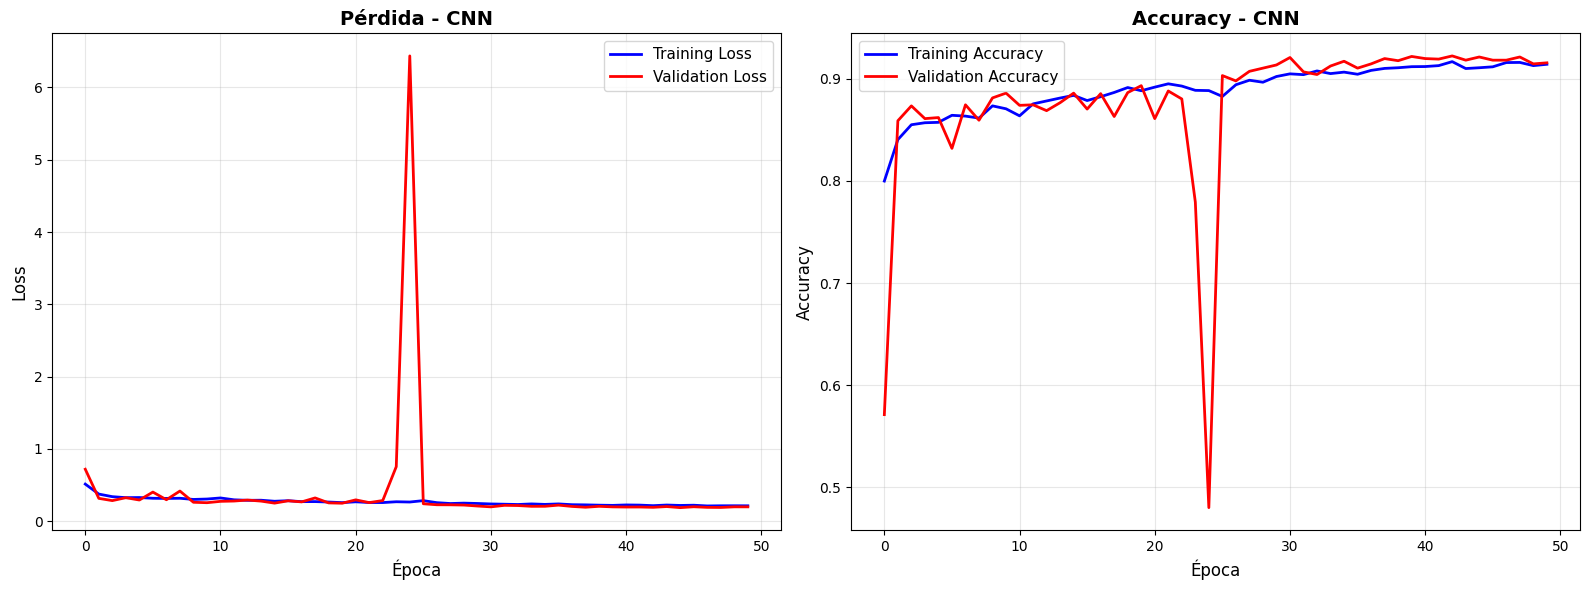

In [17]:
print("="*80)
print("EVALUACIÓN MODELO 2: CNN")
print("="*80 + "\n")

# Evaluar
test_loss_cnn, test_accuracy_cnn = model_cnn.evaluate(X_test_normalized, y_test_categorical, verbose=0)

print(f"📊 Resultados CNN en Test:")
print(f"   Loss: {test_loss_cnn:.4f}")
print(f"   Accuracy: {test_accuracy_cnn:.4f} ({test_accuracy_cnn*100:.2f}%)")

# Predicciones
print("\nRealizando predicciones CNN...")
y_pred_proba_cnn = model_cnn.predict(X_test_normalized, verbose=0)
y_pred_cnn = np.argmax(y_pred_proba_cnn, axis=1)

# Métricas
accuracy_cnn = accuracy_score(y_test_labels, y_pred_cnn)
precision_cnn, recall_cnn, f1_cnn, _ = precision_recall_fscore_support(
    y_test_labels, y_pred_cnn, average='macro', zero_division=0
)

print(f"\n📊 Métricas Globales CNN:")
print(f"   Accuracy: {accuracy_cnn:.4f}")
print(f"   Precision (macro): {precision_cnn:.4f}")
print(f"   Recall (macro): {recall_cnn:.4f}")
print(f"   F1-Score (macro): {f1_cnn:.4f}")

# Curvas de aprendizaje
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(history_cnn.history['loss'], label='Training Loss', linewidth=2, color='blue')
ax1.plot(history_cnn.history['val_loss'], label='Validation Loss', linewidth=2, color='red')
ax1.set_title('Pérdida - CNN', fontsize=14, fontweight='bold')
ax1.set_xlabel('Época', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

ax2.plot(history_cnn.history['accuracy'], label='Training Accuracy', linewidth=2, color='blue')
ax2.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy', linewidth=2, color='red')
ax2.set_title('Accuracy - CNN', fontsize=14, fontweight='bold')
ax2.set_xlabel('Época', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*80)

## MODELO 3: Transfer Learning con CNN Pre-entrenada

Ejemplos de Data Augmentation aplicado a una imagen:



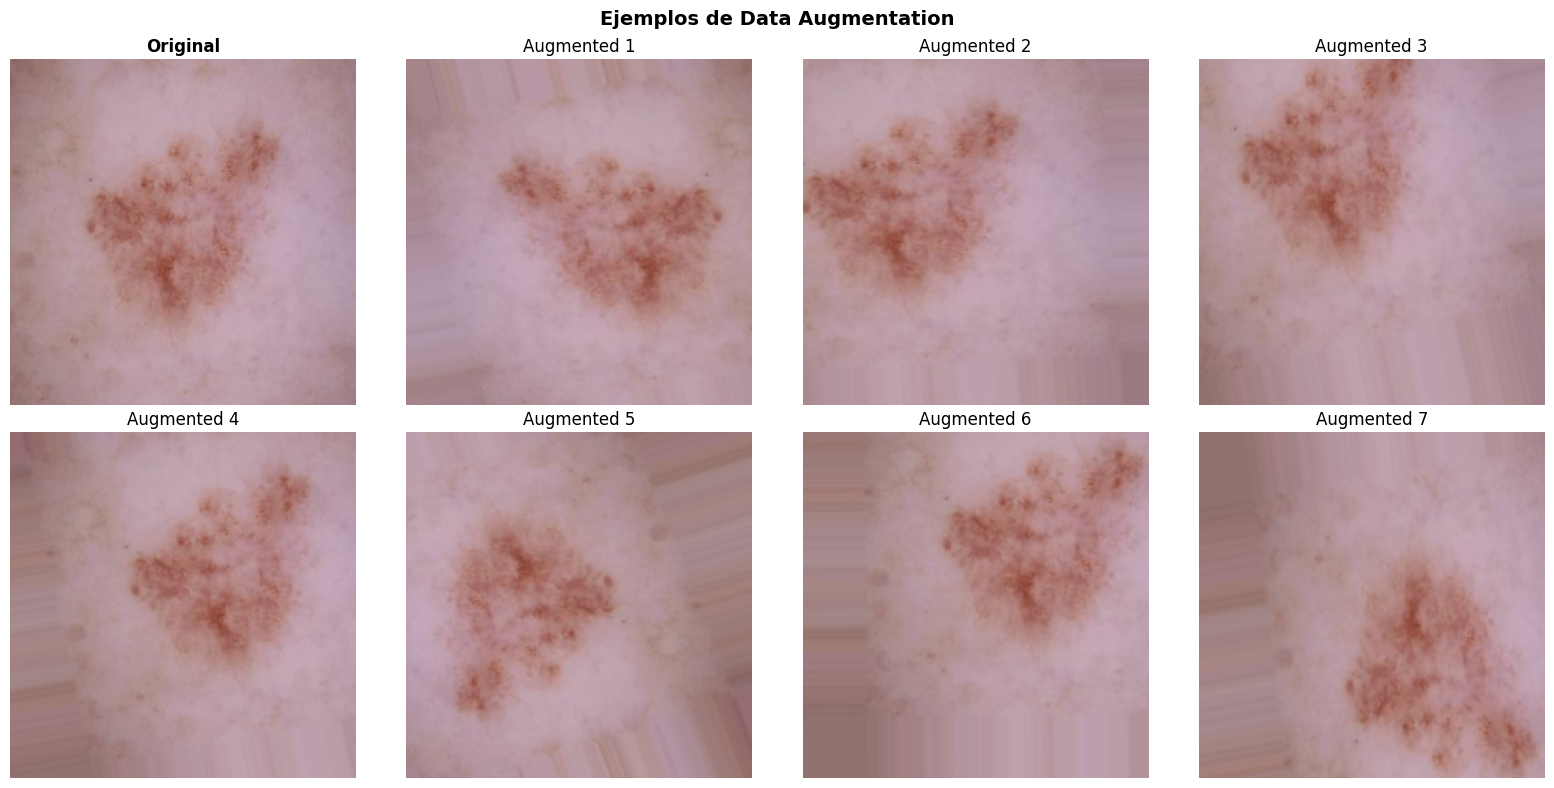

In [18]:
# Visualizar ejemplos de Data Augmentation
print("Ejemplos de Data Augmentation aplicado a una imagen:\n")

# Tomar una imagen de ejemplo
sample_img = X_train_final[0:1]  # Shape (1, 224, 224, 3)
sample_label = y_train_final[0:1]

# Generar versiones augmentadas
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Original
axes[0, 0].imshow(sample_img[0])
axes[0, 0].set_title('Original', fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

# Generar 7 versiones augmentadas
aug_gen = train_datagen.flow(sample_img, sample_label, batch_size=1)

for i in range(7):
    row = (i + 1) // 4
    col = (i + 1) % 4
    aug_img = next(aug_gen)[0][0]
    axes[row, col].imshow(aug_img)
    axes[row, col].set_title(f'Augmented {i+1}', fontsize=12)
    axes[row, col].axis('off')

plt.suptitle('Ejemplos de Data Augmentation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## Construcción del Modelo 3: Transfer Learning

In [19]:
print("="*80)
print("MODELO 3: TRANSFER LEARNING - CONSTRUCCIÓN")
print("="*80 + "\n")

print("Modelos pre-entrenados disponibles:")
print("  1. VGG16 - 138M parámetros (clásico, simple)")
print("  2. ResNet50 - 25.6M parámetros (residual connections)")
print("  3. EfficientNetB0 - 5.3M parámetros (eficiente, moderno)")
print("  4. MobileNetV2 - 3.5M parámetros (ligero, rápido)\n")

# Elegir modelo base (puedes cambiar esto)
MODEL_NAME = 'MobileNetV2'  # Opciones: 'VGG16', 'ResNet50', 'EfficientNetB0', 'MobileNetV2'

print(f"Modelo seleccionado: {MODEL_NAME}\n")

# Cargar modelo base pre-entrenado (sin la capa superior de clasificación)
if MODEL_NAME == 'VGG16':
    base_model = VGG16(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
elif MODEL_NAME == 'ResNet50':
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
elif MODEL_NAME == 'EfficientNetB0':
    base_model = EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
elif MODEL_NAME == 'MobileNetV2':
    base_model = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

print(f"✅ Modelo base '{MODEL_NAME}' cargado con pesos de ImageNet")

# Congelar las capas del modelo base (Transfer Learning)
print("\nCongelando capas del modelo base...")
base_model.trainable = False

print(f"✅ Capas congeladas: {len(base_model.layers)}")
print("   Solo entrenaremos las nuevas capas superiores\n")

# Construir el modelo completo
print("Construyendo modelo con capas personalizadas...")

model_transfer = models.Sequential([
    # Modelo base pre-entrenado
    base_model,
    
    # Capas de pooling y clasificación personalizadas
    layers.GlobalAveragePooling2D(name='global_avg_pool'),
    
    layers.Dense(512, activation='relu', name='dense1'),
    layers.BatchNormalization(name='bn1'),
    layers.Dropout(0.5, name='dropout1'),
    
    layers.Dense(256, activation='relu', name='dense2'),
    layers.BatchNormalization(name='bn2'),
    layers.Dropout(0.5, name='dropout2'),
    
    # Capa de salida
    layers.Dense(len(MAP_CLASSES), activation='softmax', name='output')
], name=f'TransferLearning_{MODEL_NAME}')

# Compilar el modelo
model_transfer.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n✅ Modelo Transfer Learning compilado")
print("\n--- Resumen del Modelo Transfer Learning ---")
model_transfer.summary()

# Información de parámetros
trainable_params_transfer = np.sum([np.prod(v.shape) for v in model_transfer.trainable_weights])
non_trainable_params_transfer = np.sum([np.prod(v.shape) for v in model_transfer.non_trainable_weights])

print(f"\n📊 Parámetros del modelo Transfer Learning:")
print(f"   Totales: {trainable_params_transfer + non_trainable_params_transfer:,}")
print(f"   Entrenables: {trainable_params_transfer:,}")
print(f"   No entrenables (congelados): {non_trainable_params_transfer:,}")
print(f"   Porcentaje entrenable: {trainable_params_transfer/(trainable_params_transfer + non_trainable_params_transfer)*100:.2f}%")

print("\n" + "="*80)

MODELO 3: TRANSFER LEARNING - CONSTRUCCIÓN

Modelos pre-entrenados disponibles:
  1. VGG16 - 138M parámetros (clásico, simple)
  2. ResNet50 - 25.6M parámetros (residual connections)
  3. EfficientNetB0 - 5.3M parámetros (eficiente, moderno)
  4. MobileNetV2 - 3.5M parámetros (ligero, rápido)

Modelo seleccionado: MobileNetV2

✅ Modelo base 'MobileNetV2' cargado con pesos de ImageNet

Congelando capas del modelo base...
✅ Capas congeladas: 154
   Solo entrenaremos las nuevas capas superiores

Construyendo modelo con capas personalizadas...

✅ Modelo Transfer Learning compilado

--- Resumen del Modelo Transfer Learning ---
Model: "TransferLearning_MobileNetV2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_224 (Funct  (None, 7, 7, 1280)       2257984   
 ional)                                                          
                                                                 
 g

## Entrenamiento del Modelo 3: Transfer Learning

In [20]:
print("="*80)
print("ENTRENAMIENTO MODELO 3: TRANSFER LEARNING")
print("="*80 + "\n")

# Configurar callbacks
callbacks_transfer = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

print("Callbacks configurados:")
print("  • EarlyStopping: patience=10, restore_best_weights=True")
print("  • ReduceLROnPlateau: factor=0.5, patience=5\n")

print("Iniciando entrenamiento Transfer Learning...\n")
print(f"Épocas máximas: {EPOCHS}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Usando GPU: {len(tf.config.list_physical_devices('GPU')) > 0}\n")
print("="*80 + "\n")

# Entrenar el modelo
history_transfer = model_transfer.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks_transfer,
    verbose=1
)

print("\n" + "="*80)
print("ENTRENAMIENTO TRANSFER LEARNING COMPLETADO")
print("="*80)

ENTRENAMIENTO MODELO 3: TRANSFER LEARNING

Callbacks configurados:
  • EarlyStopping: patience=10, restore_best_weights=True
  • ReduceLROnPlateau: factor=0.5, patience=5

Iniciando entrenamiento Transfer Learning...

Épocas máximas: 50
Batch size: 32
Usando GPU: True


Epoch 1/50
241/241 [==============================] - 42s 167ms/step - loss: 0.4804 - accuracy: 0.8199 - val_loss: 0.3656 - val_accuracy: 0.8568 - lr: 0.0010
Epoch 2/50
241/241 [==============================] - 40s 167ms/step - loss: 0.3487 - accuracy: 0.8611 - val_loss: 0.2806 - val_accuracy: 0.8834 - lr: 0.0010
Epoch 3/50
241/241 [==============================] - 40s 168ms/step - loss: 0.3187 - accuracy: 0.8667 - val_loss: 0.2681 - val_accuracy: 0.8860 - lr: 0.0010
Epoch 4/50
241/241 [==============================] - 40s 167ms/step - loss: 0.2969 - accuracy: 0.8787 - val_loss: 0.2636 - val_accuracy: 0.8803 - lr: 0.0010
Epoch 5/50
241/241 [==============================] - 40s 167ms/step - loss: 0.2984 - accuracy: 0

## Análisis de Curvas de Aprendizaje - Transfer Learning

ANÁLISIS DE CURVAS DE APRENDIZAJE - TRANSFER LEARNING



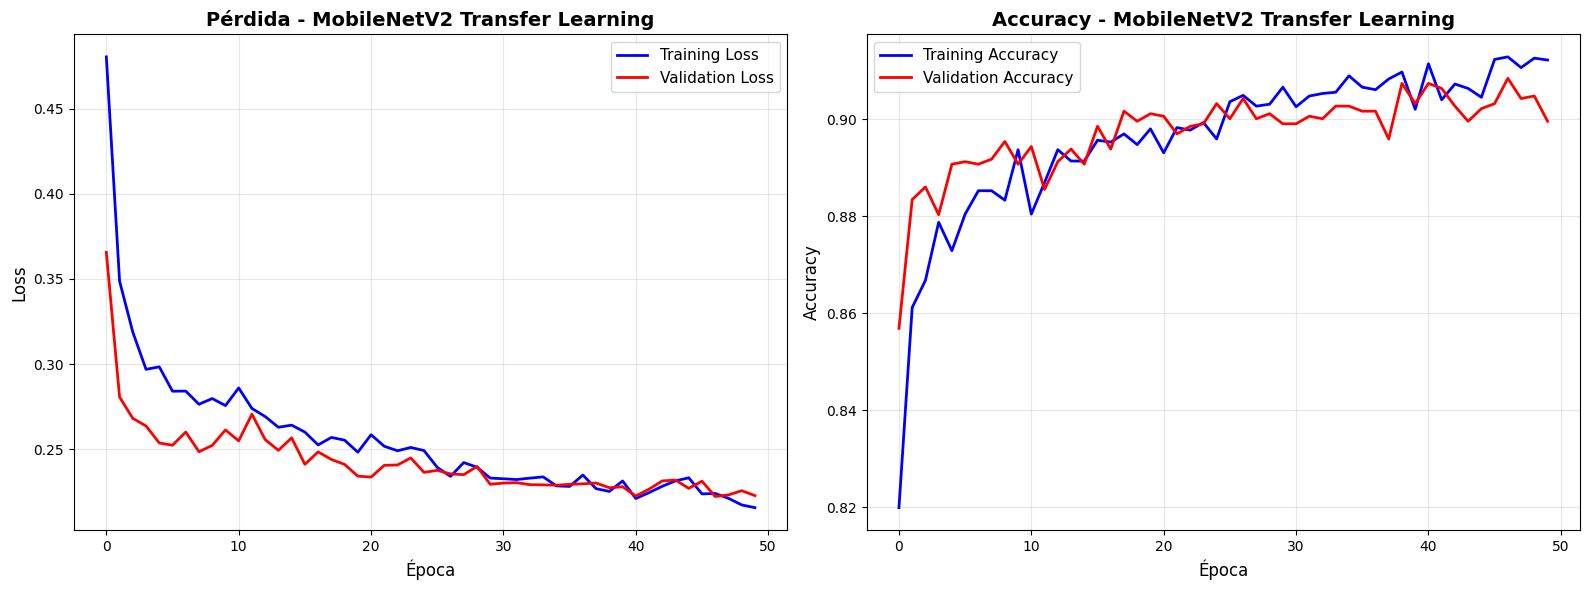

Épocas entrenadas: 50
Mejor época: 47
Mejor val_loss: 0.2222
Mejor val_accuracy: 0.9084 (90.84%)

Accuracy final Training: 0.9122
Accuracy final Validation: 0.8995
Diferencia: 0.0126
✅ Modelo bien generalizado



In [21]:
print("="*80)
print("ANÁLISIS DE CURVAS DE APRENDIZAJE - TRANSFER LEARNING")
print("="*80 + "\n")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de pérdida
ax1.plot(history_transfer.history['loss'], label='Training Loss', linewidth=2, color='blue')
ax1.plot(history_transfer.history['val_loss'], label='Validation Loss', linewidth=2, color='red')
ax1.set_title(f'Pérdida - {MODEL_NAME} Transfer Learning', fontsize=14, fontweight='bold')
ax1.set_xlabel('Época', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Gráfico de accuracy
ax2.plot(history_transfer.history['accuracy'], label='Training Accuracy', linewidth=2, color='blue')
ax2.plot(history_transfer.history['val_accuracy'], label='Validation Accuracy', linewidth=2, color='red')
ax2.set_title(f'Accuracy - {MODEL_NAME} Transfer Learning', fontsize=14, fontweight='bold')
ax2.set_xlabel('Época', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Estadísticas del entrenamiento
epochs_trained = len(history_transfer.history['loss'])
best_epoch = np.argmin(history_transfer.history['val_loss'])
best_val_loss = history_transfer.history['val_loss'][best_epoch]
best_val_acc = history_transfer.history['val_accuracy'][best_epoch]

print(f"Épocas entrenadas: {epochs_trained}")
print(f"Mejor época: {best_epoch + 1}")
print(f"Mejor val_loss: {best_val_loss:.4f}")
print(f"Mejor val_accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")

# Análisis de overfitting
final_train_acc = history_transfer.history['accuracy'][-1]
final_val_acc = history_transfer.history['val_accuracy'][-1]
diff_acc = final_train_acc - final_val_acc

print(f"\nAccuracy final Training: {final_train_acc:.4f}")
print(f"Accuracy final Validation: {final_val_acc:.4f}")
print(f"Diferencia: {diff_acc:.4f}")

if diff_acc > 0.1:
    print("⚠️ Posible overfitting detectado (diferencia > 10%)")
elif diff_acc > 0.05:
    print("⚠️ Ligero overfitting (diferencia > 5%)")
else:
    print("✅ Modelo bien generalizado")

print("\n" + "="*80)

## Evaluación del Modelo 3: Transfer Learning

In [22]:
print("="*80)
print("EVALUACIÓN MODELO 3: TRANSFER LEARNING EN TEST")
print("="*80 + "\n")

# Evaluar el modelo
test_loss_transfer, test_accuracy_transfer = model_transfer.evaluate(X_test_normalized, y_test_categorical, verbose=0)

print(f"📊 Resultados Transfer Learning en Test:")
print(f"   Loss: {test_loss_transfer:.4f}")
print(f"   Accuracy: {test_accuracy_transfer:.4f} ({test_accuracy_transfer*100:.2f}%)")

# Realizar predicciones
print("\nRealizando predicciones Transfer Learning...")
y_pred_proba_transfer = model_transfer.predict(X_test_normalized, verbose=0)
y_pred_transfer = np.argmax(y_pred_proba_transfer, axis=1)

# Calcular métricas
accuracy_transfer = accuracy_score(y_test_labels, y_pred_transfer)
precision_transfer, recall_transfer, f1_transfer, support = precision_recall_fscore_support(
    y_test_labels, y_pred_transfer, average='macro', zero_division=0
)

print(f"\n📊 Métricas Globales Transfer Learning:")
print(f"   Accuracy: {accuracy_transfer:.4f}")
print(f"   Precision (macro): {precision_transfer:.4f}")
print(f"   Recall (macro): {recall_transfer:.4f}")
print(f"   F1-Score (macro): {f1_transfer:.4f}")

print("\n" + "="*80)

EVALUACIÓN MODELO 3: TRANSFER LEARNING EN TEST

📊 Resultados Transfer Learning en Test:
   Loss: 0.2254
   Accuracy: 0.9050 (90.50%)

Realizando predicciones Transfer Learning...

📊 Métricas Globales Transfer Learning:
   Accuracy: 0.9050
   Precision (macro): 0.9059
   Recall (macro): 0.9050
   F1-Score (macro): 0.9049



## COMPARACIÓN DE LOS 3 MODELOS

COMPARACIÓN COMPLETA DE LOS 3 MODELOS

--- TABLA COMPARATIVA ---

                         Modelo  Test Accuracy  Precision (macro)  Recall (macro)  F1-Score (macro)  Test Loss  Parámetros Entrenables
                   DNN (Densas)          0.909           0.910025           0.909          0.908943   0.221856                77237122
               CNN (desde cero)          0.908           0.914371           0.908          0.907645   0.225710                26997218
Transfer Learning (MobileNetV2)          0.905           0.905859           0.905          0.904950   0.225406                  789250

🏆 MEJOR MODELO: DNN (Densas)
   Accuracy: 0.9090 (90.90%)


C:\Users\TRENDINGPC\AppData\Local\Temp\ipykernel_10204\1258861458.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(resultados_comparacion['Modelo'], rotation=15, ha='right')
C:\Users\TRENDINGPC\AppData\Local\Temp\ipykernel_10204\1258861458.py:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax4.set_xticklabels(resultados_comparacion['Modelo'], rotation=15, ha='right')
C:\Users\TRENDINGPC\AppData\Local\Temp\ipykernel_10204\1258861458.py:138: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax7.set_xticklabels(resultados_comparacion['Modelo'], rotation=15, ha='right')


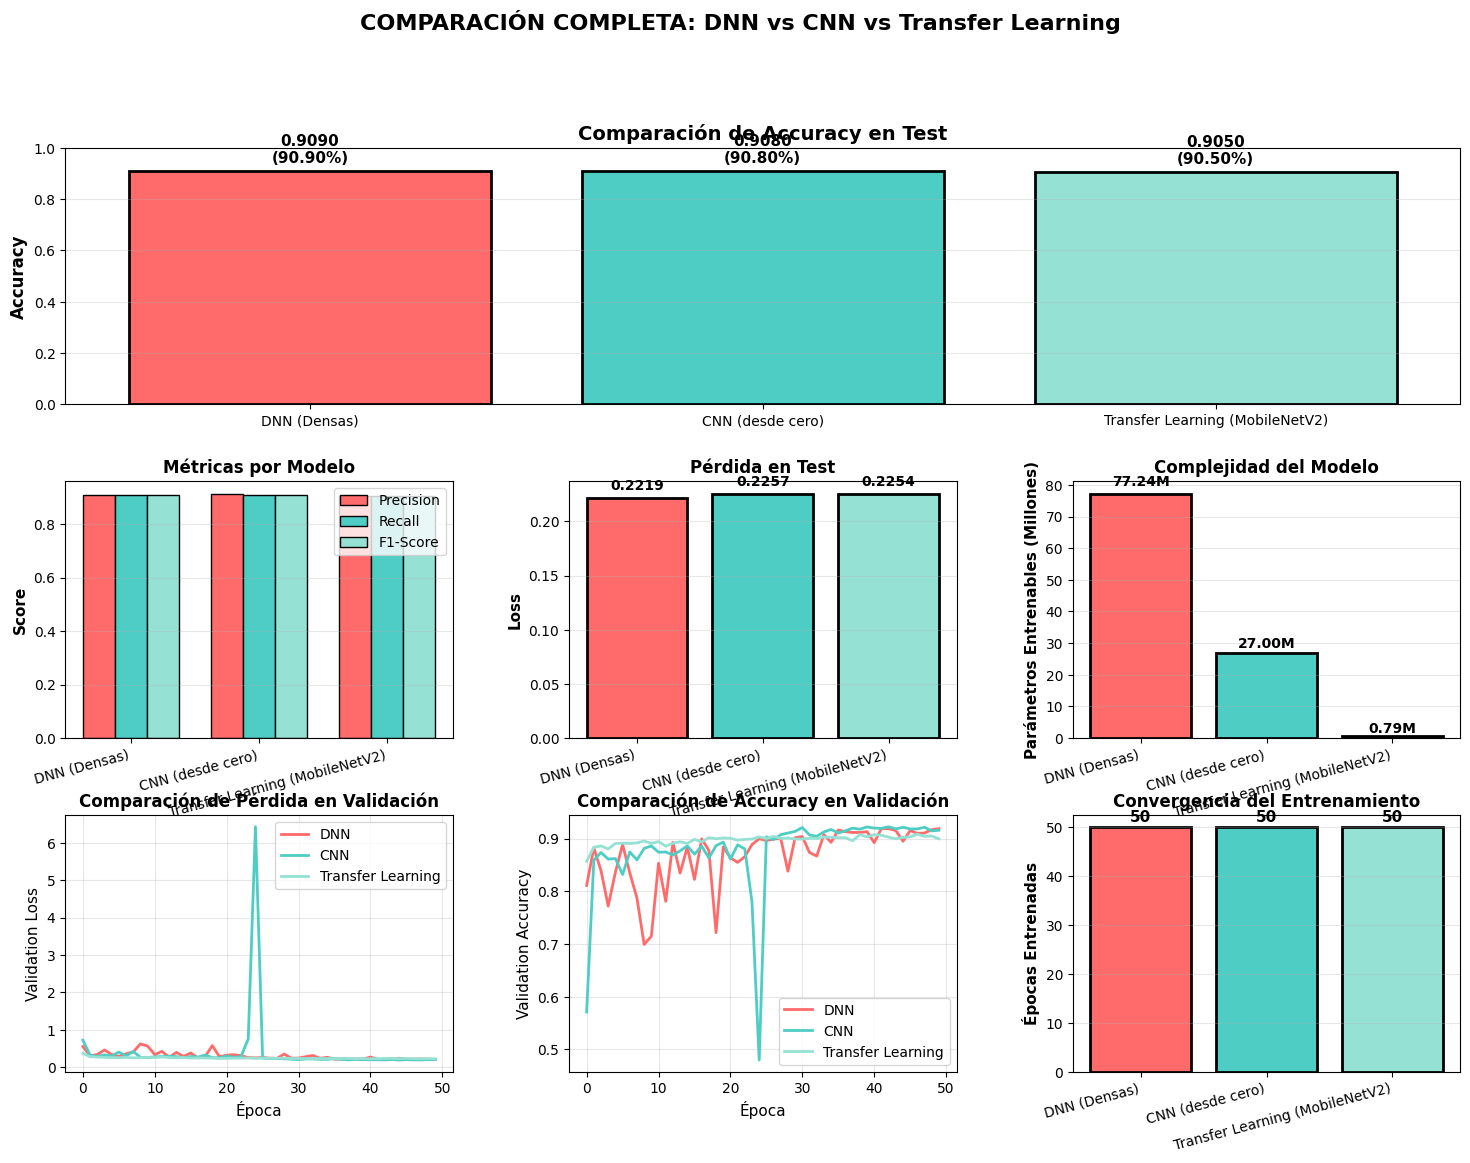

In [23]:
print("="*80)
print("COMPARACIÓN COMPLETA DE LOS 3 MODELOS")
print("="*80 + "\n")

# Crear DataFrame con resultados
resultados_comparacion = pd.DataFrame({
    'Modelo': ['DNN (Densas)', 'CNN (desde cero)', f'Transfer Learning ({MODEL_NAME})'],
    'Test Accuracy': [test_accuracy_dnn, test_accuracy_cnn, test_accuracy_transfer],
    'Precision (macro)': [precision_dnn, precision_cnn, precision_transfer],
    'Recall (macro)': [recall_dnn, recall_cnn, recall_transfer],
    'F1-Score (macro)': [f1_dnn, f1_cnn, f1_transfer],
    'Test Loss': [test_loss_dnn, test_loss_cnn, test_loss_transfer],
    'Parámetros Entrenables': [
        trainable_params_dnn,
        trainable_params_cnn,
        trainable_params_transfer
    ]
})

print("--- TABLA COMPARATIVA ---\n")
print(resultados_comparacion.to_string(index=False))

# Identificar el mejor modelo
best_model_idx = resultados_comparacion['Test Accuracy'].idxmax()
best_model_name = resultados_comparacion.loc[best_model_idx, 'Modelo']
best_accuracy = resultados_comparacion.loc[best_model_idx, 'Test Accuracy']

print(f"\n🏆 MEJOR MODELO: {best_model_name}")
print(f"   Accuracy: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")

# Visualización comparativa
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Comparación de Accuracy
ax1 = fig.add_subplot(gs[0, :])
colors_bars = ['#FF6B6B', '#4ECDC4', '#95E1D3']
bars = ax1.bar(resultados_comparacion['Modelo'], 
               resultados_comparacion['Test Accuracy'], 
               color=colors_bars, edgecolor='black', linewidth=2)
ax1.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax1.set_title('Comparación de Accuracy en Test', fontsize=14, fontweight='bold')
ax1.set_ylim(0, 1)
ax1.grid(axis='y', alpha=0.3)
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{height:.4f}\n({height*100:.2f}%)',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# 2. Comparación de métricas (Precision, Recall, F1)
ax2 = fig.add_subplot(gs[1, 0])
x = np.arange(len(resultados_comparacion))
width = 0.25
ax2.bar(x - width, resultados_comparacion['Precision (macro)'], width, 
        label='Precision', color='#FF6B6B', edgecolor='black')
ax2.bar(x, resultados_comparacion['Recall (macro)'], width, 
        label='Recall', color='#4ECDC4', edgecolor='black')
ax2.bar(x + width, resultados_comparacion['F1-Score (macro)'], width, 
        label='F1-Score', color='#95E1D3', edgecolor='black')
ax2.set_ylabel('Score', fontsize=11, fontweight='bold')
ax2.set_title('Métricas por Modelo', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(resultados_comparacion['Modelo'], rotation=15, ha='right')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# 3. Comparación de Loss
ax3 = fig.add_subplot(gs[1, 1])
bars_loss = ax3.bar(resultados_comparacion['Modelo'], 
                    resultados_comparacion['Test Loss'],
                    color=colors_bars, edgecolor='black', linewidth=2)
ax3.set_ylabel('Loss', fontsize=11, fontweight='bold')
ax3.set_title('Pérdida en Test', fontsize=12, fontweight='bold')
ax3.set_xticklabels(resultados_comparacion['Modelo'], rotation=15, ha='right')
ax3.grid(axis='y', alpha=0.3)
for bar in bars_loss:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + height*0.02,
             f'{height:.4f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# 4. Comparación de parámetros
ax4 = fig.add_subplot(gs[1, 2])
params_millions = resultados_comparacion['Parámetros Entrenables'] / 1_000_000
bars_params = ax4.bar(resultados_comparacion['Modelo'], 
                      params_millions,
                      color=colors_bars, edgecolor='black', linewidth=2)
ax4.set_ylabel('Parámetros Entrenables (Millones)', fontsize=11, fontweight='bold')
ax4.set_title('Complejidad del Modelo', fontsize=12, fontweight='bold')
ax4.set_xticklabels(resultados_comparacion['Modelo'], rotation=15, ha='right')
ax4.grid(axis='y', alpha=0.3)
for bar in bars_params:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + height*0.02,
             f'{height:.2f}M',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# 5-7. Curvas de aprendizaje comparativas
histories = [
    ('DNN', history_dnn, '#FF6B6B'),
    ('CNN', history_cnn, '#4ECDC4'),
    ('Transfer Learning', history_transfer, '#95E1D3')
]

# Loss comparison
ax5 = fig.add_subplot(gs[2, 0])
for name, hist, color in histories:
    ax5.plot(hist.history['val_loss'], label=name, linewidth=2, color=color)
ax5.set_xlabel('Época', fontsize=11)
ax5.set_ylabel('Validation Loss', fontsize=11)
ax5.set_title('Comparación de Pérdida en Validación', fontsize=12, fontweight='bold')
ax5.legend()
ax5.grid(True, alpha=0.3)

# Accuracy comparison
ax6 = fig.add_subplot(gs[2, 1])
for name, hist, color in histories:
    ax6.plot(hist.history['val_accuracy'], label=name, linewidth=2, color=color)
ax6.set_xlabel('Época', fontsize=11)
ax6.set_ylabel('Validation Accuracy', fontsize=11)
ax6.set_title('Comparación de Accuracy en Validación', fontsize=12, fontweight='bold')
ax6.legend()
ax6.grid(True, alpha=0.3)

# Training time / epochs
ax7 = fig.add_subplot(gs[2, 2])
epochs_trained = [
    len(history_dnn.history['loss']),
    len(history_cnn.history['loss']),
    len(history_transfer.history['loss'])
]
bars_epochs = ax7.bar(resultados_comparacion['Modelo'], 
                      epochs_trained,
                      color=colors_bars, edgecolor='black', linewidth=2)
ax7.set_ylabel('Épocas Entrenadas', fontsize=11, fontweight='bold')
ax7.set_title('Convergencia del Entrenamiento', fontsize=12, fontweight='bold')
ax7.set_xticklabels(resultados_comparacion['Modelo'], rotation=15, ha='right')
ax7.grid(axis='y', alpha=0.3)
for bar in bars_epochs:
    height = bar.get_height()
    ax7.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{int(height)}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.suptitle('COMPARACIÓN COMPLETA: DNN vs CNN vs Transfer Learning', 
             fontsize=16, fontweight='bold', y=0.995)
plt.show()

print("\n" + "="*80)

## Matrices de Confusión Comparativas

MATRICES DE CONFUSIÓN COMPARATIVAS



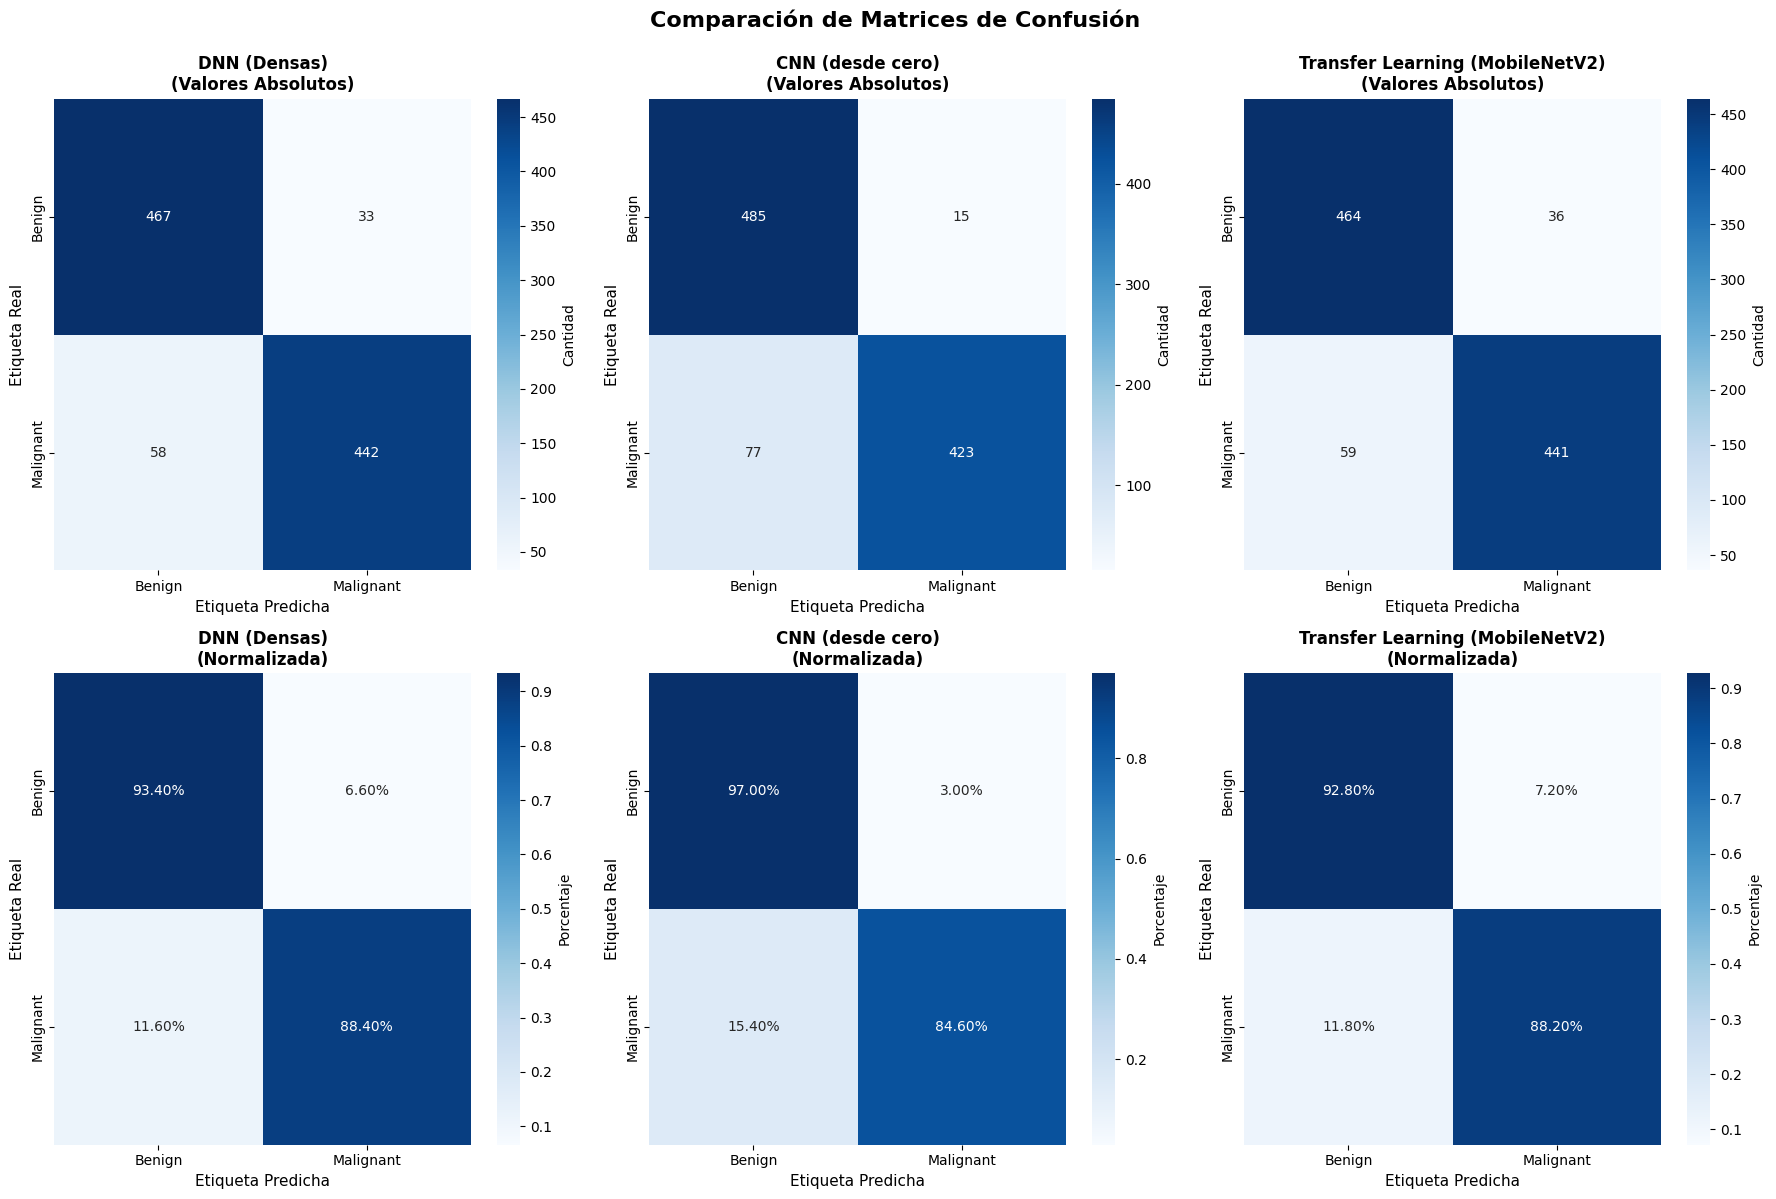

In [24]:
print("="*80)
print("MATRICES DE CONFUSIÓN COMPARATIVAS")
print("="*80 + "\n")

class_names_list = [CLASS_NAMES[i] for i in sorted(MAP_CLASSES.keys())]

# Calcular matrices de confusión
cm_dnn = confusion_matrix(y_test_labels, y_pred_dnn)
cm_cnn = confusion_matrix(y_test_labels, y_pred_cnn)
cm_transfer = confusion_matrix(y_test_labels, y_pred_transfer)

# Visualización comparativa
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Normalizar matrices
matrices = [
    (cm_dnn, 'DNN (Densas)'),
    (cm_cnn, 'CNN (desde cero)'),
    (cm_transfer, f'Transfer Learning ({MODEL_NAME})')
]

# Fila 1: Valores absolutos
for idx, (cm, title) in enumerate(matrices):
    ax = axes[0, idx]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names_list,
                yticklabels=class_names_list,
                cbar_kws={'label': 'Cantidad'},
                ax=ax)
    ax.set_title(f'{title}\n(Valores Absolutos)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Etiqueta Real', fontsize=11)
    ax.set_xlabel('Etiqueta Predicha', fontsize=11)

# Fila 2: Valores normalizados
for idx, (cm, title) in enumerate(matrices):
    ax = axes[1, idx]
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
                xticklabels=class_names_list,
                yticklabels=class_names_list,
                cbar_kws={'label': 'Porcentaje'},
                ax=ax)
    ax.set_title(f'{title}\n(Normalizada)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Etiqueta Real', fontsize=11)
    ax.set_xlabel('Etiqueta Predicha', fontsize=11)

plt.suptitle('Comparación de Matrices de Confusión', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n" + "="*80)

## Visualización Comparativa de Predicciones

VISUALIZACIÓN COMPARATIVA DE PREDICCIONES



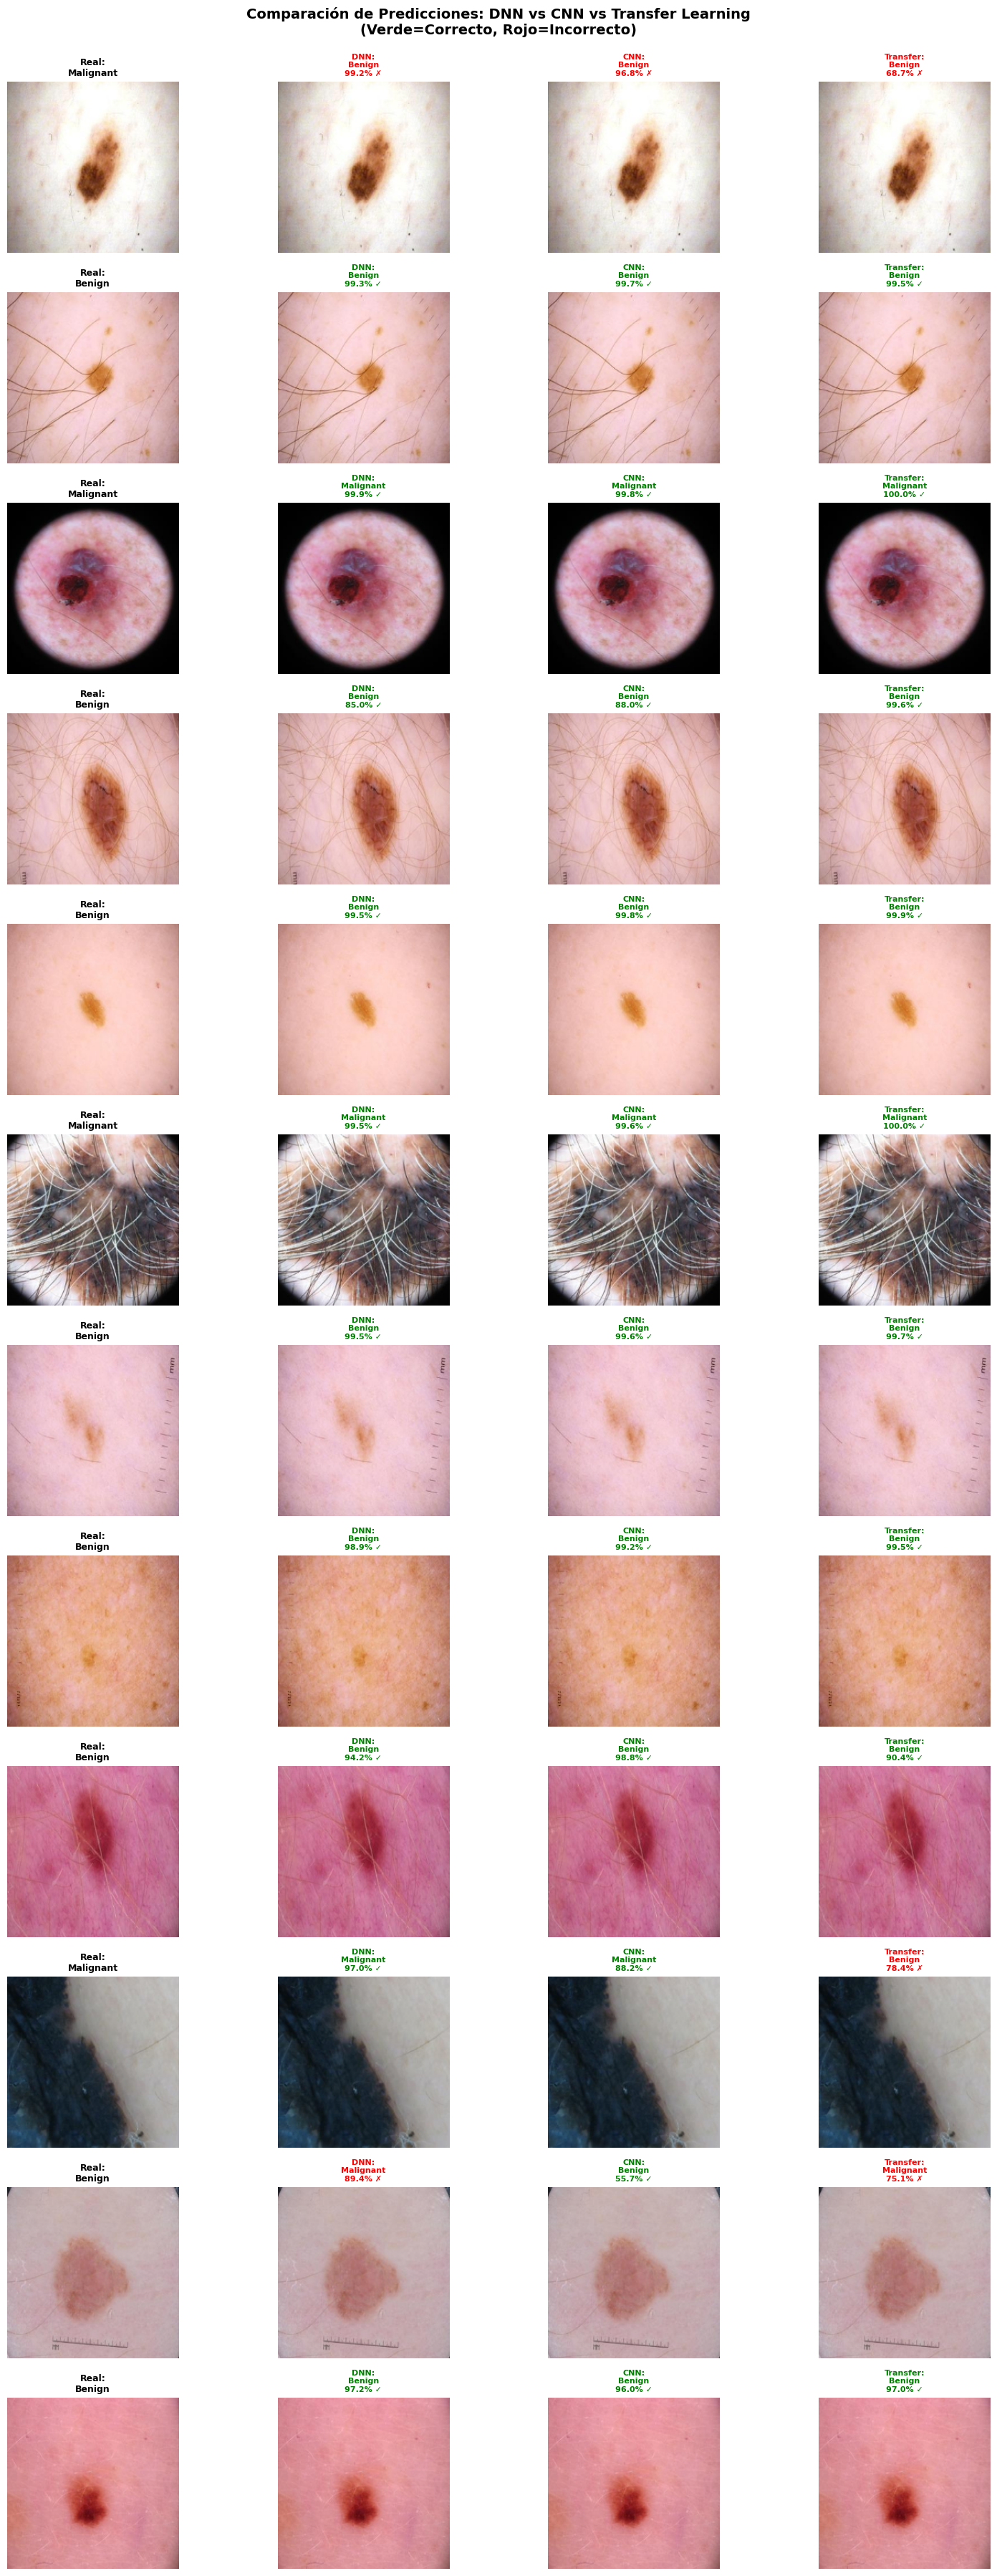

📊 Estadísticas de predicciones correctas:
   DNN: 909/1000 (90.90%)
   CNN: 908/1000 (90.80%)
   Transfer Learning: 905/1000 (90.50%)

📊 Análisis de acuerdos:
   Todos los modelos aciertan: 850/1000 (85.00%)
   Todos los modelos fallan: 46/1000 (4.60%)



In [25]:
print("="*80)
print("VISUALIZACIÓN COMPARATIVA DE PREDICCIONES")
print("="*80 + "\n")

# Desnormalizar para visualización
X_test_display = (X_test_normalized * 255).astype(np.uint8)

# Seleccionar muestras aleatorias
np.random.seed(42)
num_samples = min(12, len(X_test_normalized))
random_indices = np.random.choice(len(X_test_normalized), num_samples, replace=False)

# Visualizar comparación de los 3 modelos
fig, axes = plt.subplots(num_samples, 4, figsize=(16, num_samples * 3))

for i, idx in enumerate(random_indices):
    # Imagen original
    ax = axes[i, 0] if num_samples > 1 else axes[0]
    ax.imshow(X_test_display[idx])
    true_label = CLASS_NAMES[y_test_labels[idx]]
    ax.set_title(f'Real:\n{true_label}', fontsize=9, fontweight='bold')
    ax.axis('off')
    
    # Predicciones de cada modelo
    predictions = [
        (y_pred_dnn[idx], y_pred_proba_dnn[idx], 'DNN'),
        (y_pred_cnn[idx], y_pred_proba_cnn[idx], 'CNN'),
        (y_pred_transfer[idx], y_pred_proba_transfer[idx], 'Transfer')
    ]
    
    for j, (pred, proba, name) in enumerate(predictions):
        ax = axes[i, j + 1] if num_samples > 1 else axes[j + 1]
        ax.imshow(X_test_display[idx])
        
        pred_label = CLASS_NAMES[pred]
        confidence = proba[pred] * 100
        
        is_correct = pred == y_test_labels[idx]
        color = 'green' if is_correct else 'red'
        symbol = '✓' if is_correct else '✗'
        
        title = f'{name}:\n{pred_label}\n{confidence:.1f}% {symbol}'
        ax.set_title(title, fontsize=8, color=color, fontweight='bold')
        ax.axis('off')

plt.suptitle('Comparación de Predicciones: DNN vs CNN vs Transfer Learning\n(Verde=Correcto, Rojo=Incorrecto)',
             fontsize=14, fontweight='bold', y=0.998)
plt.tight_layout()
plt.show()

# Estadísticas de aciertos por modelo
print("📊 Estadísticas de predicciones correctas:")
print(f"   DNN: {np.sum(y_pred_dnn == y_test_labels)}/{len(y_test_labels)} ({np.mean(y_pred_dnn == y_test_labels)*100:.2f}%)")
print(f"   CNN: {np.sum(y_pred_cnn == y_test_labels)}/{len(y_test_labels)} ({np.mean(y_pred_cnn == y_test_labels)*100:.2f}%)")
print(f"   Transfer Learning: {np.sum(y_pred_transfer == y_test_labels)}/{len(y_test_labels)} ({np.mean(y_pred_transfer == y_test_labels)*100:.2f}%)")

# Casos donde todos aciertan / todos fallan
todos_correctos = (y_pred_dnn == y_test_labels) & (y_pred_cnn == y_test_labels) & (y_pred_transfer == y_test_labels)
todos_incorrectos = (y_pred_dnn != y_test_labels) & (y_pred_cnn != y_test_labels) & (y_pred_transfer != y_test_labels)

print(f"\n📊 Análisis de acuerdos:")
print(f"   Todos los modelos aciertan: {np.sum(todos_correctos)}/{len(y_test_labels)} ({np.mean(todos_correctos)*100:.2f}%)")
print(f"   Todos los modelos fallan: {np.sum(todos_incorrectos)}/{len(y_test_labels)} ({np.mean(todos_incorrectos)*100:.2f}%)")

print("\n" + "="*80)

## Análisis Detallado por Clase

ANÁLISIS DETALLADO POR CLASE

--- Métricas por Clase - MODELO DNN ---
              precision    recall  f1-score   support

      Benign       0.89      0.93      0.91       500
   Malignant       0.93      0.88      0.91       500

    accuracy                           0.91      1000
   macro avg       0.91      0.91      0.91      1000
weighted avg       0.91      0.91      0.91      1000


--- Métricas por Clase - MODELO CNN ---
              precision    recall  f1-score   support

      Benign       0.86      0.97      0.91       500
   Malignant       0.97      0.85      0.90       500

    accuracy                           0.91      1000
   macro avg       0.91      0.91      0.91      1000
weighted avg       0.91      0.91      0.91      1000


--- Métricas por Clase - MODELO TRANSFER LEARNING ---
              precision    recall  f1-score   support

      Benign       0.89      0.93      0.91       500
   Malignant       0.92      0.88      0.90       500

    accuracy    

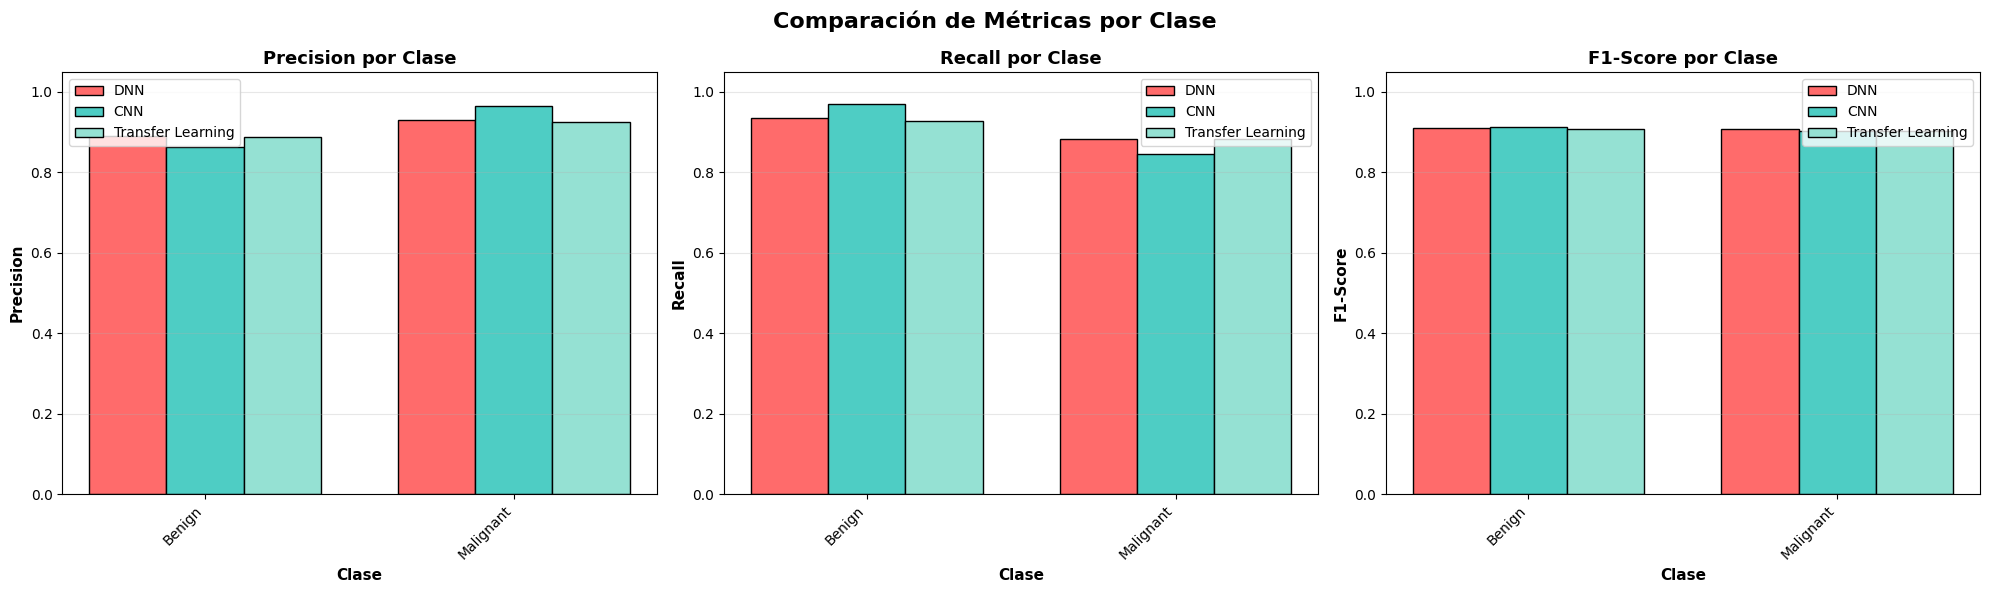

In [26]:
print("="*80)
print("ANÁLISIS DETALLADO POR CLASE")
print("="*80 + "\n")

class_names_list = [CLASS_NAMES[i] for i in sorted(MAP_CLASSES.keys())]

# Calcular métricas por clase para cada modelo
print("--- Métricas por Clase - MODELO DNN ---")
print(classification_report(y_test_labels, y_pred_dnn, 
                          target_names=class_names_list, 
                          zero_division=0))

print("\n--- Métricas por Clase - MODELO CNN ---")
print(classification_report(y_test_labels, y_pred_cnn, 
                          target_names=class_names_list, 
                          zero_division=0))

print("\n--- Métricas por Clase - MODELO TRANSFER LEARNING ---")
print(classification_report(y_test_labels, y_pred_transfer, 
                          target_names=class_names_list, 
                          zero_division=0))

# Comparación visual de F1-Score por clase
precision_dnn_per_class, recall_dnn_per_class, f1_dnn_per_class, _ = \
    precision_recall_fscore_support(y_test_labels, y_pred_dnn, average=None, zero_division=0)
    
precision_cnn_per_class, recall_cnn_per_class, f1_cnn_per_class, _ = \
    precision_recall_fscore_support(y_test_labels, y_pred_cnn, average=None, zero_division=0)
    
precision_transfer_per_class, recall_transfer_per_class, f1_transfer_per_class, _ = \
    precision_recall_fscore_support(y_test_labels, y_pred_transfer, average=None, zero_division=0)

# Crear DataFrame comparativo
df_comparison_per_class = pd.DataFrame({
    'Clase': class_names_list * 3,
    'Modelo': ['DNN'] * len(class_names_list) + ['CNN'] * len(class_names_list) + ['Transfer Learning'] * len(class_names_list),
    'Precision': np.concatenate([precision_dnn_per_class, precision_cnn_per_class, precision_transfer_per_class]),
    'Recall': np.concatenate([recall_dnn_per_class, recall_cnn_per_class, recall_transfer_per_class]),
    'F1-Score': np.concatenate([f1_dnn_per_class, f1_cnn_per_class, f1_transfer_per_class])
})

# Visualización
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

metrics = ['Precision', 'Recall', 'F1-Score']
colors = {'DNN': '#FF6B6B', 'CNN': '#4ECDC4', 'Transfer Learning': '#95E1D3'}

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    
    x = np.arange(len(class_names_list))
    width = 0.25
    
    for i, modelo in enumerate(['DNN', 'CNN', 'Transfer Learning']):
        data = df_comparison_per_class[df_comparison_per_class['Modelo'] == modelo][metric].values
        offset = (i - 1) * width
        ax.bar(x + offset, data, width, label=modelo, color=colors[modelo], edgecolor='black')
    
    ax.set_xlabel('Clase', fontsize=11, fontweight='bold')
    ax.set_ylabel(metric, fontsize=11, fontweight='bold')
    ax.set_title(f'{metric} por Clase', fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(class_names_list, rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, 1.05)

plt.suptitle('Comparación de Métricas por Clase', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*80)